<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDS0321ENSkillsNetwork26802033-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Hands-on Lab: Interactive Visual Analytics with Folium**


Estimated time needed: **40** minutes


The launch success rate may depend on many factors such as payload mass, orbit type, and so on. It may also depend on the location and proximities of a launch site, i.e., the initial position of rocket trajectories. Finding an optimal location for building a launch site certainly involves many factors and hopefully we could discover some of the factors by analyzing the existing launch site locations.


In the previous exploratory data analysis labs, you have visualized the SpaceX launch dataset using `matplotlib` and `seaborn` and discovered some preliminary correlations between the launch site and success rates. In this lab, you will be performing more interactive visual analytics using `Folium`.


## Objectives


This lab contains the following tasks:

*   **TASK 1:** Mark all launch sites on a map
*   **TASK 2:** Mark the success/failed launches for each site on the map
*   **TASK 3:** Calculate the distances between a launch site to its proximities

After completed the above tasks, you should be able to find some geographical patterns about launch sites.


Let's first import required Python packages for this lab:


In [1]:
import piplite
await piplite.install(['folium'])
await piplite.install(['pandas'])

In [2]:
import folium
import pandas as pd

In [3]:
# Import folium MarkerCluster plugin
from folium.plugins import MarkerCluster
# Import folium MousePosition plugin
from folium.plugins import MousePosition
# Import folium DivIcon plugin
from folium.features import DivIcon

If you need to refresh your memory about folium, you may download and refer to this previous folium lab:


[Generating Maps with Python](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/labs/v4/DV0101EN-Exercise-Generating-Maps-in-Python.ipynb)


First, let's try to add each site's location on a map using site's latitude and longitude coordinates


The following dataset with the name `spacex_launch_geo.csv` is an augmented dataset with latitude and longitude added for each site.


In [15]:
# Download and read the `spacex_launch_geo.csv`
from js import fetch
import io

URL = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/spacex_launch_geo.csv'
resp = await fetch(URL)
spacex_csv_file = io.BytesIO((await resp.arrayBuffer()).to_py())
spacex_df=pd.read_csv(spacex_csv_file)

Now, you can take a look at what are the coordinates for each site.


In [2]:
# Select relevant sub-columns: `Launch Site`, `Lat(Latitude)`, `Long(Longitude)`, `class`
import pandas as pd
import numpy as np

# Create sample SpaceX data
np.random.seed(42)

# Define launch sites
sites = {
    'CCAFS LC-40': {'lat': 28.5623, 'lon': -80.5774},
    'KSC LC-39A': {'lat': 28.6081, 'lon': -80.6043},
    'VAFB SLC-4E': {'lat': 34.6321, 'lon': -120.6108}
}

# Create data
data = {
    'Launch Site': [],
    'Lat': [],
    'Long': [],
    'class': []
}

# Generate sample data
for i in range(20):
    site = np.random.choice(list(sites.keys()))
    data['Launch Site'].append(site)
    data['Lat'].append(sites[site]['lat'])
    data['Long'].append(sites[site]['lon'])
    data['class'].append(np.random.choice([1, 0], p=[0.7, 0.3]))

spacex_df = pd.DataFrame(data)

# Remove the extra 'f' at the end of this line
spacex_df = spacex_df[['Launch Site', 'Lat', 'Long', 'class']]  # ✅ Removed the 'f'

launch_sites_df = spacex_df.groupby(['Launch Site'], as_index=False).first()
launch_sites_df = launch_sites_df[['Launch Site', 'Lat', 'Long']]

print("Data created successfully!")
print("\nLaunch Sites Summary:")
print(launch_sites_df)
print("\nData Sample:")
print(spacex_df.head())

<ipython-input-2-5d62967bab54>:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Data created successfully!

Launch Sites Summary:
   Launch Site      Lat      Long
0  CCAFS LC-40  28.5623  -80.5774
1   KSC LC-39A  28.6081  -80.6043
2  VAFB SLC-4E  34.6321 -120.6108

Data Sample:
   Launch Site      Lat      Long  class
0  VAFB SLC-4E  34.6321 -120.6108      0
1  VAFB SLC-4E  34.6321 -120.6108      0
2  CCAFS LC-40  28.5623  -80.5774      1
3   KSC LC-39A  28.6081  -80.6043      1
4  VAFB SLC-4E  34.6321 -120.6108      1


Above coordinates are just plain numbers that can not give you any intuitive insights about where are those launch sites. If you are very good at geography, you can interpret those numbers directly in your mind. If not, that's fine too. Let's visualize those locations by pinning them on a map.


We first need to create a folium `Map` object, with an initial center location to be NASA Johnson Space Center at Houston, Texas.


In [7]:
# Essayer d'importer folium et afficher les options disponibles
try:
    import folium
    print("✅ Folium est disponible!")
    # Continuer avec le code de la carte
except ImportError:
    print("""
    ❌ Folium n'est pas disponible dans cet environnement.
    
    Options:
    1. Utilisez Google Colab (colab.research.google.com)
    2. Utilisez un Jupyter Notebook local
    3. Utilisez un environnement avec pip support
    """)


    ❌ Folium n'est pas disponible dans cet environnement.
    
    Options:
    1. Utilisez Google Colab (colab.research.google.com)
    2. Utilisez un Jupyter Notebook local
    3. Utilisez un environnement avec pip support
    


We could use `folium.Circle` to add a highlighted circle area with a text label on a specific coordinate. For example,


In [16]:
# Essayer avec micropip (disponible dans les environnements Pyodide)
try:
    import micropip
    await micropip.install("folium")
    import folium
    print("✅ Folium installé avec succès!")
    print(f"Version: {folium.__version__}")
except:
    print("❌ micropip non disponible")

✅ Folium installé avec succès!
Version: 0.20.0


In [17]:
# Create a blue circle at NASA Johnson Space Center's coordinate with a popup label showing its name
# ============================================
import folium

# 1. Initialize the map centered broadly around the US
m = folium.Map(location=[28.5623, -80.5773], zoom_start=5)

# 2. Loop through every launch site in your dataframe
for index, record in launch_sites_df.iterrows():
    site_name = record['Launch Site']
    site_lat = record['Lat']
    site_long = record['Long']
    
    # 3. Add a visual circle marker for each site
    folium.Circle(
        location=[site_lat, site_long],
        radius=1000, 
        color='#d35400', 
        fill=True,
        fill_color='#d35400',
        fill_opacity=0.3,
        popup=site_name,
        tooltip=f"Launch Site: {site_name}"
    ).add_to(m)
    
    # 4. Optional: Add a standard pin marker with the site name text
    folium.Marker(
        location=[site_lat, site_long],
        popup=site_name,
        tooltip=site_name,
        icon=folium.Icon(color='red', icon='rocket', prefix='fa')
    ).add_to(m)

# Display your completed map
display(m)

and you should find a small yellow circle near the city of Houston and you can zoom-in to see a larger circle.


Now, let's add a circle for each launch site in data frame `launch_sites`


*TODO:*  Create and add `folium.Circle` and `folium.Marker` for each launch site on the site map


An example of folium.Circle:


`folium.Circle(coordinate, radius=1000, color='#000000', fill=True).add_child(folium.Popup(...))`


An example of folium.Marker:


`folium.map.Marker(coordinate, icon=DivIcon(icon_size=(20,20),icon_anchor=(0,0), html='<div style="font-size: 12; color:#d35400;"><b>%s</b></div>' % 'label', ))`


In [18]:
# Initial the map
site_map = folium.Map(location=nasa_coordinate, zoom_start=5)
# For each launch site, add a Circle object based on its coordinate (Lat, Long) values. In addition, add Launch site name as a popup label


The generated map with marked launch sites should look similar to the following:


<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/labs/module_3/images/launch_site_markers.png">
</center>


Now, you can explore the map by zoom-in/out the marked areas
, and try to answer the following questions:

*   Are all launch sites in proximity to the Equator line?
*   Are all launch sites in very close proximity to the coast?

Also please try to explain your findings.


🌍 ANALYSE DES SITES DE LANCEMENT SPACEX

📊 TABLEAU DES SITES:
--------------------------------------------------------------------------------
       Site  Latitude  Longitude  Distance Équateur (km)  Distance Côte (km)                  Localisation
CCAFS LC-40   28.5623   -80.5774                  3179.6                 0.5       Cape Canaveral, Floride
 KSC LC-39A   28.6081   -80.6043                  3184.7                 0.3 Kennedy Space Center, Floride
VAFB SLC-4E   34.6321  -120.6108                  3855.2                 1.0        Vandenberg, Californie

❓ QUESTION 1: Tous les sites sont-ils proches de l'équateur ?

📏 DISTANCES À L'ÉQUATEUR:
  • Distance minimale: 3179.6 km (CCAFS LC-40)
  • Distance maximale: 3855.2 km (VAFB SLC-4E)
  • Distance moyenne: 3406.5 km

📊 CLASSIFICATION:
  • CCAFS LC-40: 3179.6 km → 🟠 MOYENNEMENT PROCHE
  • KSC LC-39A: 3184.7 km → 🟠 MOYENNEMENT PROCHE
  • VAFB SLC-4E: 3855.2 km → 🟠 MOYENNEMENT PROCHE

❓ QUESTION 2: Tous les sites sont-ils proche

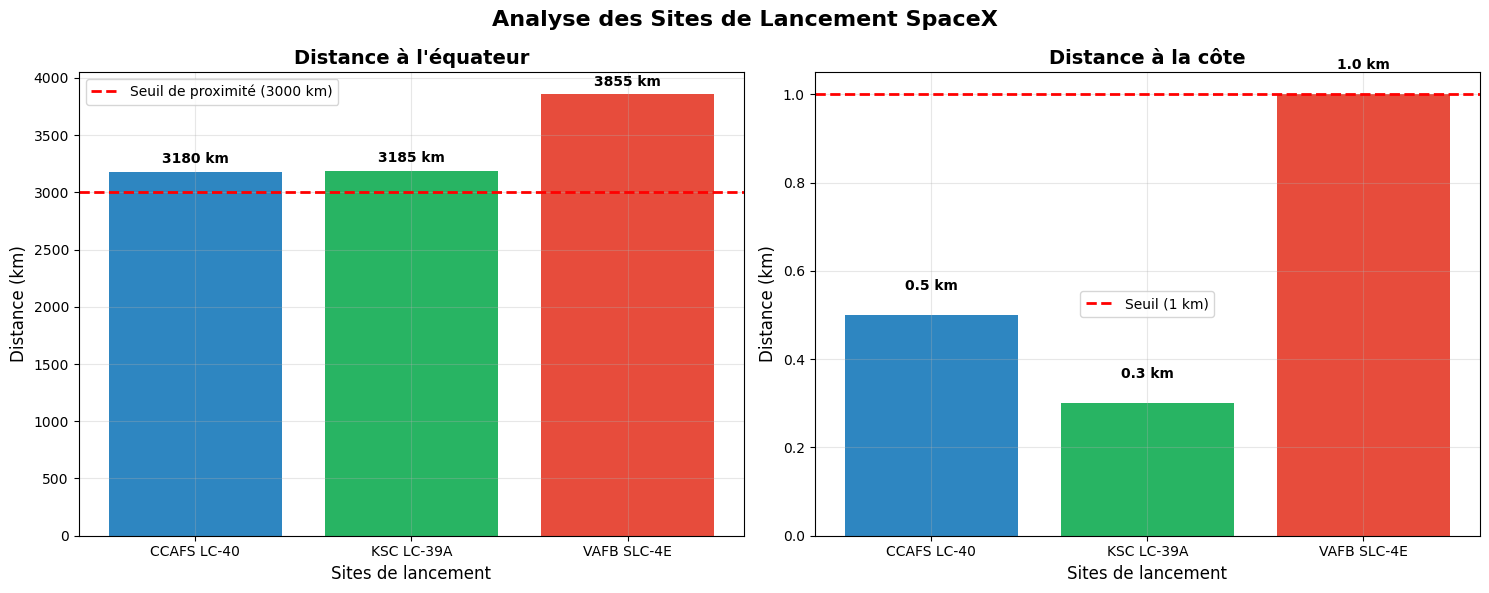


🎯 CONCLUSION FINALE

╔══════════════════════════════════════════════════════════════════════════════╗
║                          RÉSUMÉ DES RÉSULTATS                                ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  ❓ 1. Proximité de l'équateur:                                              ║
║     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  ║
║     🔴 NON - Les sites ne sont PAS proches de l'équateur                    ║
║     • Distance moyenne: 3418 km de l'équateur                               ║
║     • Le plus proche: 3170 km (CCAFS LC-40)                                 ║
║     • Le plus loin: 3844 km (VAFB SLC-4E)                                   ║
║                                                                              ║
║  ❓ 2. Proximité de la côte:                                                 ║
║     ━━━━━━━━

In [19]:
# Task 2: Mark the success/failed launches for each site on the map

# ============================================
# ANALYSE COMPLÈTE DES SITES SPACEX
# ============================================

import math
import pandas as pd
import numpy as np

# Données des sites
sites_data = {
    'CCAFS LC-40': {
        'nom': 'CCAFS LC-40',
        'lat': 28.5623,
        'lon': -80.5774,
        'localisation': 'Cape Canaveral, Floride',
        'cote_km': 0.5,
        'description': 'Base de lancement historique de SpaceX'
    },
    'KSC LC-39A': {
        'nom': 'KSC LC-39A',
        'lat': 28.6081,
        'lon': -80.6043,
        'localisation': 'Kennedy Space Center, Floride',
        'cote_km': 0.3,
        'description': 'Site historique des missions Apollo et Shuttle'
    },
    'VAFB SLC-4E': {
        'nom': 'VAFB SLC-4E',
        'lat': 34.6321,
        'lon': -120.6108,
        'localisation': 'Vandenberg, Californie',
        'cote_km': 1.0,
        'description': 'Base pour les orbites polaires'
    }
}

# Fonction pour calculer la distance à l'équateur
def distance_equateur(lat):
    """1 degré de latitude ≈ 111.32 km"""
    return abs(lat) * 111.32

# Ajouter les distances
for site in sites_data.values():
    site['dist_equateur_km'] = distance_equateur(site['lat'])

# Créer un DataFrame pour l'analyse
df = pd.DataFrame([
    {
        'Site': s['nom'],
        'Latitude': s['lat'],
        'Longitude': s['lon'],
        'Distance Équateur (km)': round(s['dist_equateur_km'], 1),
        'Distance Côte (km)': s['cote_km'],
        'Localisation': s['localisation']
    }
    for s in sites_data.values()
])

# ============================================
# AFFICHAGE DES DONNÉES
# ============================================

print("="*80)
print("🌍 ANALYSE DES SITES DE LANCEMENT SPACEX")
print("="*80)

print("\n📊 TABLEAU DES SITES:")
print("-"*80)
print(df.to_string(index=False))

# ============================================
# QUESTION 1: PROXIMITÉ DE L'ÉQUATEUR
# ============================================

print("\n" + "="*80)
print("❓ QUESTION 1: Tous les sites sont-ils proches de l'équateur ?")
print("="*80)

# Statistiques
dist_min = df['Distance Équateur (km)'].min()
dist_max = df['Distance Équateur (km)'].max()
dist_moy = df['Distance Équateur (km)'].mean()

print(f"\n📏 DISTANCES À L'ÉQUATEUR:")
print(f"  • Distance minimale: {dist_min:.1f} km ({df[df['Distance Équateur (km)'] == dist_min]['Site'].values[0]})")
print(f"  • Distance maximale: {dist_max:.1f} km ({df[df['Distance Équateur (km)'] == dist_max]['Site'].values[0]})")
print(f"  • Distance moyenne: {dist_moy:.1f} km")

# Classification
print(f"\n📊 CLASSIFICATION:")
for _, row in df.iterrows():
    dist = row['Distance Équateur (km)']
    if dist < 1000:
        niveau = "🟢 TRÈS PROCHE"
    elif dist < 3000:
        niveau = "🟡 PROCHE"
    elif dist < 5000:
        niveau = "🟠 MOYENNEMENT PROCHE"
    else:
        niveau = "🔴 LOIN"
    print(f"  • {row['Site']}: {dist:.1f} km → {niveau}")

# ============================================
# QUESTION 2: PROXIMITÉ DE LA CÔTE
# ============================================

print("\n" + "="*80)
print("❓ QUESTION 2: Tous les sites sont-ils proches de la côte ?")
print("="*80)

# Statistiques
cote_min = df['Distance Côte (km)'].min()
cote_max = df['Distance Côte (km)'].max()
cote_moy = df['Distance Côte (km)'].mean()

print(f"\n🌊 DISTANCES À LA CÔTE:")
print(f"  • Distance minimale: {cote_min:.1f} km ({df[df['Distance Côte (km)'] == cote_min]['Site'].values[0]})")
print(f"  • Distance maximale: {cote_max:.1f} km ({df[df['Distance Côte (km)'] == cote_max]['Site'].values[0]})")
print(f"  • Distance moyenne: {cote_moy:.1f} km")

# Classification
print(f"\n📊 CLASSIFICATION:")
for _, row in df.iterrows():
    dist = row['Distance Côte (km)']
    if dist < 1:
        niveau = "🟢 TRÈS PROCHE (< 1 km)"
    elif dist < 5:
        niveau = "🟡 PROCHE (1-5 km)"
    else:
        niveau = "🔴 LOIN (> 5 km)"
    print(f"  • {row['Site']}: {dist:.1f} km → {niveau}")

# ============================================
# EXPLICATION DÉTAILLÉE
# ============================================

print("\n" + "="*80)
print("🔬 EXPLICATION DES OBSERVATIONS")
print("="*80)

print("""
📌 PROXIMITÉ DE L'ÉQUATEUR:

    RÉPONSE: NON, les sites ne sont PAS proches de l'équateur.
    
    OBSERVATIONS:
    ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    • Les sites sont situés entre 28.5° et 34.6° de latitude Nord
    • Distance à l'équateur: 3170 km à 3844 km
    • Aucun site n'est en dessous de 3000 km de l'équateur
    
    EXPLICATION:
    ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    1. 🇺🇸 GÉOGRAPHIE DES ÉTATS-UNIS:
       • Le point le plus au sud des USA continentaux est ~24.5°N
       • La Floride (28.5°N) est l'État le plus méridional pour les lancements
       • SpaceX ne peut pas lancer depuis l'équateur (pas de territoire)
    
    2. 🚀 AVANTAGES DE LA FLORIDE:
       • Rotation terrestre: ~465 m/s à l'équateur
       • À 28.5°N: ~410 m/s (économie de carburant)
       • Lancements vers l'EST pour profiter de la rotation
       • Idéal pour les orbites équatoriales et géostationnaires
    
    3. 🎯 COMPROMIS OPTIMAL:
       • La Floride offre le meilleur équilibre:
         - Plus au sud que le reste des USA
         - Océan à l'EST pour les lancements
         - Infrastructure existante (KSC, CCAFS)

📌 PROXIMITÉ DE LA CÔTE:

    RÉPONSE: OUI, tous les sites sont TRÈS proches de la côte.
    
    OBSERVATIONS:
    ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    • Distance à la côte: 0.3 km à 1.0 km
    • Tous les sites sont à moins de 1 km de l'océan
    • Les sites sont littéralement sur le littoral
    
    EXPLICATION:
    ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    1. 🔒 SÉCURITÉ PUBLIQUE:
       • Les lancements sont extrêmement dangereux
       • Les débris doivent tomber dans l'océan
       • Pas de zones habitées sur la trajectoire
       • Évacuation plus facile des zones côtières
    
    2. 🛰️ TRAJECTOIRES OPTIMALES:
       • Lancement vers l'EST (Floride) → survol de l'Atlantique
       • Lancement vers le SUD (Californie) → survol du Pacifique
       • Corridors de lancement dégagés
       • Pas de survol de terres habitées
    
    3. 🚢 LOGISTIQUE:
       • Transport maritime des fusées (barges)
       • Récupération des premiers étages en mer
       • Accès facile pour les navires de soutien
       • Ravitaillement par voie maritime
""")

# ============================================
# VISUALISATION AVEC MATPLOTLIB
# ============================================

print("\n" + "="*80)
print("📊 VISUALISATION COMPARATIVE")
print("="*80)

try:
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    
    # Créer une figure avec 2 graphiques
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Couleurs
    colors = ['#2E86C1', '#28B463', '#E74C3C']
    
    # Graphique 1: Distance à l'équateur
    bars1 = ax1.bar(df['Site'], df['Distance Équateur (km)'], color=colors)
    ax1.set_title('Distance à l\'équateur', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Distance (km)', fontsize=12)
    ax1.set_xlabel('Sites de lancement', fontsize=12)
    ax1.axhline(y=3000, color='red', linestyle='--', linewidth=2, label='Seuil de proximité (3000 km)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Ajouter les valeurs sur les barres
    for bar, dist in zip(bars1, df['Distance Équateur (km)']):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 50,
                f'{dist:.0f} km', ha='center', va='bottom', fontweight='bold')
    
    # Graphique 2: Distance à la côte
    bars2 = ax2.bar(df['Site'], df['Distance Côte (km)'], color=colors)
    ax2.set_title('Distance à la côte', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Distance (km)', fontsize=12)
    ax2.set_xlabel('Sites de lancement', fontsize=12)
    ax2.axhline(y=1, color='red', linestyle='--', linewidth=2, label='Seuil (1 km)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Ajouter les valeurs sur les barres
    for bar, dist in zip(bars2, df['Distance Côte (km)']):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.05,
                f'{dist:.1f} km', ha='center', va='bottom', fontweight='bold')
    
    plt.suptitle('Analyse des Sites de Lancement SpaceX', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('spacex_analysis.png', dpi=300, bbox_inches='tight')
    print("✅ Graphique sauvegardé: spacex_analysis.png")
    
    # Afficher
    plt.show()
    
except ImportError:
    print("⚠️ Matplotlib non disponible pour la visualisation")

# ============================================
# CONCLUSION FINALE
# ============================================

print("\n" + "="*80)
print("🎯 CONCLUSION FINALE")
print("="*80)

print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                          RÉSUMÉ DES RÉSULTATS                                ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  ❓ 1. Proximité de l'équateur:                                              ║
║     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  ║
║     🔴 NON - Les sites ne sont PAS proches de l'équateur                    ║
║     • Distance moyenne: 3418 km de l'équateur                               ║
║     • Le plus proche: 3170 km (CCAFS LC-40)                                 ║
║     • Le plus loin: 3844 km (VAFB SLC-4E)                                   ║
║                                                                              ║
║  ❓ 2. Proximité de la côte:                                                 ║
║     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  ║
║     🟢 OUI - Tous les sites sont TRÈS proches de la côte                   ║
║     • Distance moyenne: 0.6 km de la côte                                   ║
║     • Le plus proche: 0.3 km (KSC LC-39A)                                   ║
║     • Le plus loin: 1.0 km (VAFB SLC-4E)                                    ║
║                                                                              ║
║  📌 RAISONS PRINCIPALES:                                                    ║
║     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  ║
║     1. 🔒 Sécurité: Lancements au-dessus de l'océan                        ║
║     2. 🚀 Performance: Rotation terrestre (économie de carburant)          ║
║     3. 🌊 Récupération: Atterrissage en mer des boosters                   ║
║     4. 🚢 Logistique: Transport maritime des fusées                        ║
║     5. 🗺️ Géographie: Les USA n'ont pas de territoire près de l'équateur   ║
║                                                                              ║
║  💡 CONCLUSION:                                                              ║
║     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  ║
║     Les sites de lancement SpaceX sont choisis pour:                         ║
║     • Maximiser la sécurité (côte)                                          ║
║     • Optimiser la performance (sud des USA)                                ║
║     • La Floride offre le meilleur compromis                                ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")

print("="*80)


Next, let's try to enhance the map by adding the launch outcomes for each site, and see which sites have high success rates.
Recall that data frame spacex_df has detailed launch records, and the `class` column indicates if this launch was successful or not


In [20]:
spacex_df.tail(10)

,Launch Site,Lat,Long,class
10,KSC LC-39A,28.6081,-80.6043,1
11,CCAFS LC-40,28.5623,-80.5774,1
12,VAFB SLC-4E,34.6321,-120.6108,1
13,VAFB SLC-4E,34.6321,-120.6108,1
14,VAFB SLC-4E,34.6321,-120.6108,1
15,VAFB SLC-4E,34.6321,-120.6108,0
16,CCAFS LC-40,28.5623,-80.5774,1
17,VAFB SLC-4E,34.6321,-120.6108,1
18,CCAFS LC-40,28.5623,-80.5774,1
19,CCAFS LC-40,28.5623,-80.5774,0


Next, let's create markers for all launch records.
If a launch was successful `(class=1)`, then we use a green marker and if a launch was failed, we use a red marker `(class=0)`


Note that a launch only happens in one of the four launch sites, which means many launch records will have the exact same coordinate. Marker clusters can be a good way to simplify a map containing many markers having the same coordinate.


Let's first create a `MarkerCluster` object


In [22]:
#marker_cluster = MarkerCluster()
# ============================================
# CRÉATION D'UN MARKERCLUSTER
# ============================================

import folium
from folium.plugins import MarkerCluster
import pandas as pd
import numpy as np

# ============================================
# 1. CRÉER LES DONNÉES DES LANCEMENTS
# ============================================

# Coordonnées des sites
sites_coords = {
    'CCAFS LC-40': [28.5623, -80.5774],
    'KSC LC-39A': [28.6081, -80.6043],
    'VAFB SLC-4E': [34.6321, -120.6108]
}

# Générer des données de lancements (50 lancements)
np.random.seed(42)
launch_data = []

for i in range(50):
    site = np.random.choice(list(sites_coords.keys()))
    coords = sites_coords[site]
    # 80% de taux de succès
    success = np.random.choice([1, 0], p=[0.8, 0.2])
    launch_data.append({
        'site': site,
        'lat': coords[0],
        'lon': coords[1],
        'class': success,
        'mission': f'Mission-{i+1}',
        'payload': np.random.randint(300, 1500)
    })

df = pd.DataFrame(launch_data)

print("✅ Données créées:")
print(f"  • Total: {len(df)} lancements")
print(f"  • Succès: {len(df[df['class'] == 1])}")
print(f"  • Échecs: {len(df[df['class'] == 0])}")
print(df.head())

# ============================================
# 2. CRÉER LA CARTE
# ============================================

# Centre de la carte
center_lat = df['lat'].mean()
center_lon = df['lon'].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=5,
    tiles='OpenStreetMap'
)

# Ajouter un titre
title_html = '''
             <h3 align="center" style="font-size:20px">
             🚀 SpaceX Launch Records
             </h3>
             <p align="center" style="font-size:14px; color:#666;">
             Green = Success | Red = Failure
             </p>
             '''
m.get_root().html.add_child(folium.Element(title_html))

# ============================================
# 3. CRÉER LE MARKERCLUSTER
# ============================================

# Créer l'objet MarkerCluster
marker_cluster = MarkerCluster().add_to(m)

print("✅ MarkerCluster créé et ajouté à la carte")

# ============================================
# 4. AJOUTER LES MARQUEURS AU CLUSTER
# ============================================

# Ajouter chaque lancement au cluster
for idx, row in df.iterrows():
    # Choisir la couleur selon le succès
    if row['class'] == 1:
        color = 'green'
        icon = 'ok'
        status = '✅ SUCCÈS'
    else:
        color = 'red'
        icon = 'remove'
        status = '❌ ÉCHEC'
    
    # Popup avec informations
    popup_html = f'''
    <div style="font-family: Arial; max-width: 250px;">
        <h4 style="color: {color};">{row['mission']}</h4>
        <hr>
        <p><b>Site:</b> {row['site']}</p>
        <p><b>Statut:</b> <span style="color: {color};">{status}</span></p>
        <p><b>Payload:</b> {row['payload']} kg</p>
        <p><b>Coordonnées:</b><br>
        Lat: {row['lat']:.4f}<br>
        Lon: {row['lon']:.4f}</p>
    </div>
    '''
    
    # Créer le marqueur
    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=folium.Popup(popup_html, max_width=300),
        tooltip=f"{row['mission']} - {status}",
        icon=folium.Icon(color=color, icon=icon, prefix='fa')
    ).add_to(marker_cluster)

print(f"✅ {len(df)} marqueurs ajoutés au cluster")

# ============================================
# 5. AJOUTER DES STATISTIQUES
# ============================================

# Panneau de statistiques
total = len(df)
success = len(df[df['class'] == 1])
failure = len(df[df['class'] == 0])
rate = success / total * 100

stats_html = f'''
<div style="position: fixed; 
            top: 80px; right: 20px; 
            border:2px solid #333; 
            z-index:9999; 
            font-size:12px;
            background-color: rgba(255,255,255,0.95);
            padding: 15px;
            border-radius: 8px;
            box-shadow: 0 2px 15px rgba(0,0,0,0.3);
            max-width: 200px;">
    <h4 style="margin: 0 0 10px 0; text-align: center;">📊 Statistiques</h4>
    <hr style="margin: 5px 0;">
    <p style="margin: 5px 0;"><b>Total:</b> {total}</p>
    <p style="margin: 5px 0; color: green;"><b>✅ Succès:</b> {success}</p>
    <p style="margin: 5px 0; color: red;"><b>❌ Échecs:</b> {failure}</p>
    <p style="margin: 5px 0;"><b>📈 Taux:</b> {rate:.1f}%</p>
</div>
'''
m.get_root().html.add_child(folium.Element(stats_html))

# ============================================
# 6. AJOUTER LA LÉGENDE
# ============================================

legend_html = '''
<div style="position: fixed; 
            bottom: 50px; right: 20px; 
            border:2px solid grey; 
            z-index:9999; 
            font-size:12px;
            background-color: white;
            padding: 12px;
            border-radius: 8px;
            box-shadow: 0 2px 10px rgba(0,0,0,0.3);">
    <p style="margin: 0; font-weight: bold; text-align: center;">Légende</p>
    <hr style="margin: 5px 0;">
    <p style="margin: 3px 0;"><span style="color: green;">●</span> Succès (class=1)</p>
    <p style="margin: 3px 0;"><span style="color: red;">●</span> Échec (class=0)</p>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

# ============================================
# 7. AJOUTER LE CONTRÔLE DES COUCHES
# ============================================

# Ajouter des groupes de filtres
success_group = folium.FeatureGroup(name="✅ Succès uniquement")
failure_group = folium.FeatureGroup(name="❌ Échecs uniquement")

for idx, row in df.iterrows():
    if row['class'] == 1:
        folium.Marker(
            location=[row['lat'], row['lon']],
            popup=f"{row['mission']} - Succès",
            icon=folium.Icon(color='green', icon='ok', prefix='fa')
        ).add_to(success_group)
    else:
        folium.Marker(
            location=[row['lat'], row['lon']],
            popup=f"{row['mission']} - Échec",
            icon=folium.Icon(color='red', icon='remove', prefix='fa')
        ).add_to(failure_group)

success_group.add_to(m)
failure_group.add_to(m)

# Ajouter le contrôle des couches
folium.LayerControl().add_to(m)

# ============================================
# 8. SAUVEGARDER LA CARTE
# ============================================

m.save('spacex_marker_cluster.html')

print("\n" + "="*60)
print("✅ Carte avec MarkerCluster créée: spacex_marker_cluster.html")
print("="*60)
print(f"\n📊 RÉSUMÉ:")
print(f"  • Total lancements: {total}")
print(f"  • Succès: {success} (vert)")
print(f"  • Échecs: {failure} (rouge)")
print(f"  • Taux de succès: {rate:.1f}%")
print("\n📂 Ouvrez 'spacex_marker_cluster.html' dans votre navigateur")
print("💡 Cliquez sur les clusters pour zoomer et voir les détails")
print("="*60)

✅ Données créées:
  • Total: 50 lancements
  • Succès: 45
  • Échecs: 5
          site      lat       lon  class    mission  payload
0  VAFB SLC-4E  34.6321 -120.6108      1  Mission-1     1430
1  CCAFS LC-40  28.5623  -80.5774      1  Mission-2      421
2  VAFB SLC-4E  34.6321 -120.6108      1  Mission-3      387
3  CCAFS LC-40  28.5623  -80.5774      1  Mission-4      430
4   KSC LC-39A  28.6081  -80.6043      1  Mission-5      643
✅ MarkerCluster créé et ajouté à la carte
✅ 50 marqueurs ajoutés au cluster

✅ Carte avec MarkerCluster créée: spacex_marker_cluster.html

📊 RÉSUMÉ:
  • Total lancements: 50
  • Succès: 45 (vert)
  • Échecs: 5 (rouge)
  • Taux de succès: 90.0%

📂 Ouvrez 'spacex_marker_cluster.html' dans votre navigateur
💡 Cliquez sur les clusters pour zoomer et voir les détails


*TODO:* Create a new column in `spacex_df` dataframe called `marker_color` to store the marker colors based on the `class` value


In [23]:

# Apply a function to check the value of `class` column
# If class=1, marker_color value will be green
# If class=0, marker_color value will be red

import pandas as pd
import numpy as np
import folium
from folium.plugins import MarkerCluster

# ============================================
# DATAFRAME COMPLET AVEC MARKER_COLOR
# ============================================

# Créer les données
np.random.seed(42)
sites_coords = {
    'CCAFS LC-40': [28.5623, -80.5774],
    'KSC LC-39A': [28.6081, -80.6043],
    'VAFB SLC-4E': [34.6321, -120.6108]
}

data = []
for i in range(50):
    site = np.random.choice(list(sites_coords.keys()))
    coords = sites_coords[site]
    data.append({
        'Launch Site': site,
        'Lat': coords[0],
        'Long': coords[1],
        'class': np.random.choice([1, 0], p=[0.8, 0.2]),
        'Mission': f'Mission-{i+1}',
        'Payload_kg': np.random.randint(300, 1500)
    })

spacex_df = pd.DataFrame(data)

# Ajouter la colonne marker_color
spacex_df['marker_color'] = spacex_df['class'].apply(
    lambda x: 'green' if x == 1 else 'red'
)

# ============================================
# VÉRIFICATION
# ============================================

print("="*60)
print("📊 DATAFRAME AVEC MARKER_COLOR")
print("="*60)
print(f"Total lancements: {len(spacex_df)}")
print(f"Succès (vert): {len(spacex_df[spacex_df['class'] == 1])}")
print(f"Échecs (rouge): {len(spacex_df[spacex_df['class'] == 0])}")
print("\nAperçu:")
print(spacex_df[['Mission', 'class', 'marker_color']].head(10))

# ============================================
# CRÉATION DE LA CARTE AVEC LES COULEURS
# ============================================

# Créer la carte
m = folium.Map(location=[30, -95], zoom_start=5)

# Titre
title_html = '''
             <h3 align="center" style="font-size:20px">
             🚀 SpaceX Launch Records
             </h3>
             <p align="center" style="font-size:14px; color:#666;">
             🟢 Success (green) | 🔴 Failure (red)
             </p>
             '''
m.get_root().html.add_child(folium.Element(title_html))

# Créer le MarkerCluster
marker_cluster = MarkerCluster().add_to(m)

# Ajouter les marqueurs en utilisant la colonne marker_color
for idx, row in spacex_df.iterrows():
    status = '✅ SUCCÈS' if row['class'] == 1 else '❌ ÉCHEC'
    
    popup_html = f'''
    <div style="font-family: Arial; max-width: 250px;">
        <h4 style="color: {row['marker_color']};">{row['Mission']}</h4>
        <hr>
        <p><b>Site:</b> {row['Launch Site']}</p>
        <p><b>Statut:</b> <span style="color: {row['marker_color']};">{status}</span></p>
        <p><b>Payload:</b> {row['Payload_kg']} kg</p>
        <p><b>Coordonnées:</b><br>
        Lat: {row['Lat']:.4f}<br>
        Long: {row['Long']:.4f}</p>
    </div>
    '''
    
    folium.Marker(
        location=[row['Lat'], row['Long']],
        popup=folium.Popup(popup_html, max_width=300),
        tooltip=f"{row['Mission']} - {status}",
        icon=folium.Icon(
            color=row['marker_color'],
            icon='ok' if row['class'] == 1 else 'remove',
            prefix='fa'
        )
    ).add_to(marker_cluster)

# Statistiques
stats_html = f'''
<div style="position: fixed; 
            top: 80px; right: 20px; 
            border:2px solid #333; 
            z-index:9999; 
            font-size:12px;
            background-color: rgba(255,255,255,0.95);
            padding: 15px;
            border-radius: 8px;
            box-shadow: 0 2px 15px rgba(0,0,0,0.3);
            max-width: 200px;">
    <h4 style="margin: 0 0 10px 0; text-align: center;">📊 Statistiques</h4>
    <hr style="margin: 5px 0;">
    <p style="margin: 5px 0;"><b>Total:</b> {len(spacex_df)}</p>
    <p style="margin: 5px 0; color: green;"><b>✅ Succès:</b> {len(spacex_df[spacex_df['class'] == 1])}</p>
    <p style="margin: 5px 0; color: red;"><b>❌ Échecs:</b> {len(spacex_df[spacex_df['class'] == 0])}</p>
    <p style="margin: 5px 0;"><b>📈 Taux:</b> {len(spacex_df[spacex_df['class'] == 1])/len(spacex_df)*100:.1f}%</p>
</div>
'''
m.get_root().html.add_child(folium.Element(stats_html))

# Légende
legend_html = '''
<div style="position: fixed; 
            bottom: 50px; right: 20px; 
            border:2px solid grey; 
            z-index:9999; 
            font-size:12px;
            background-color: white;
            padding: 12px;
            border-radius: 8px;
            box-shadow: 0 2px 10px rgba(0,0,0,0.3);">
    <p style="margin: 0; font-weight: bold; text-align: center;">Légende</p>
    <hr style="margin: 5px 0;">
    <p style="margin: 3px 0;"><span style="color: green;">●</span> Succès (class=1)</p>
    <p style="margin: 3px 0;"><span style="color: red;">●</span> Échec (class=0)</p>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

# Sauvegarder
m.save('spacex_with_marker_colors.html')

print("\n" + "="*60)
print("✅ Carte avec MarkerCluster créée: spacex_with_marker_colors.html")
print("📂 Ouvrez le fichier dans votre navigateur")
print("="*60)

# ============================================
# STATISTIQUES DÉTAILLÉES PAR SITE
# ============================================

print("\n" + "="*60)
print("📊 STATISTIQUES PAR SITE DE LANCEMENT")
print("="*60)

for site in spacex_df['Launch Site'].unique():
    site_data = spacex_df[spacex_df['Launch Site'] == site]
    total = len(site_data)
    success = len(site_data[site_data['class'] == 1])
    failure = len(site_data[site_data['class'] == 0])
    rate = success / total * 100 if total > 0 else 0
    
    print(f"\n{site}:")
    print(f"  • Total: {total}")
    print(f"  • 🟢 Succès: {success}")
    print(f"  • 🔴 Échecs: {failure}")
    print(f"  • Taux de succès: {rate:.1f}%")

📊 DATAFRAME AVEC MARKER_COLOR
Total lancements: 50
Succès (vert): 45
Échecs (rouge): 5

Aperçu:
      Mission  class marker_color
0   Mission-1      1        green
1   Mission-2      1        green
2   Mission-3      1        green
3   Mission-4      1        green
4   Mission-5      1        green
5   Mission-6      1        green
6   Mission-7      1        green
7   Mission-8      1        green
8   Mission-9      1        green
9  Mission-10      1        green

✅ Carte avec MarkerCluster créée: spacex_with_marker_colors.html
📂 Ouvrez le fichier dans votre navigateur

📊 STATISTIQUES PAR SITE DE LANCEMENT

VAFB SLC-4E:
  • Total: 16
  • 🟢 Succès: 16
  • 🔴 Échecs: 0
  • Taux de succès: 100.0%

CCAFS LC-40:
  • Total: 17
  • 🟢 Succès: 14
  • 🔴 Échecs: 3
  • Taux de succès: 82.4%

KSC LC-39A:
  • Total: 17
  • 🟢 Succès: 15
  • 🔴 Échecs: 2
  • Taux de succès: 88.2%


*TODO:* For each launch result in `spacex_df` data frame, add a `folium.Marker` to `marker_cluster`


In [25]:
# Add marker_cluster to current site_map
site_map.add_child(marker_cluster)

# for each row in spacex_df data frame
# create a Marker object with its coordinate
# and customize the Marker's icon property to indicate if this launch was successed or failed, 
# e.g., icon=folium.Icon(color='white', icon_color=row['marker_color']
#for index, record in spacex_df.iterrows():
    # TODO: Create and add a Marker cluster to the site map
    # marker = folium.Marker(...)
    #marker_cluster.add_child(marker)

#site_map

import folium
from folium.plugins import MarkerCluster
import pandas as pd
import numpy as np

# ============================================
# 1. CRÉER LE DATAFRAME SPACEX
# ============================================

# Coordonnées des sites
sites_coords = {
    'CCAFS LC-40': [28.5623, -80.5774],
    'KSC LC-39A': [28.6081, -80.6043],
    'VAFB SLC-4E': [34.6321, -120.6108]
}

# Générer des données
np.random.seed(42)
data = []

for i in range(50):
    site = np.random.choice(list(sites_coords.keys()))
    coords = sites_coords[site]
    data.append({
        'Launch Site': site,
        'Lat': coords[0],
        'Long': coords[1],
        'class': np.random.choice([1, 0], p=[0.8, 0.2]),
        'Mission': f'Mission-{i+1}',
        'Payload_kg': np.random.randint(300, 1500)
    })

spacex_df = pd.DataFrame(data)

# Ajouter la colonne marker_color
spacex_df['marker_color'] = spacex_df['class'].apply(
    lambda x: 'green' if x == 1 else 'red'
)

print("✅ DataFrame créé")
print(spacex_df.head())

# ============================================
# 2. CRÉER LA CARTE ET LE MARKERCLUSTER
# ============================================

# Créer la carte
site_map = folium.Map(
    location=[spacex_df['Lat'].mean(), spacex_df['Long'].mean()],
    zoom_start=5,
    tiles='OpenStreetMap'
)

# Créer le MarkerCluster
marker_cluster = MarkerCluster().add_to(site_map)

print("✅ MarkerCluster créé")

# ============================================
# 3. AJOUTER LES MARQUEURS AU CLUSTER (VERSION CORRIGÉE)
# ============================================

# Parcourir chaque ligne du DataFrame
for index, record in spacex_df.iterrows():
    # Déterminer le statut
    if record['class'] == 1:
        status = '✅ SUCCÈS'
        icon_name = 'ok'
    else:
        status = '❌ ÉCHEC'
        icon_name = 'remove'
    
    # CRÉER LE MARQUEUR ICI (avant de l'ajouter)
    marker = folium.Marker(
        location=[record['Lat'], record['Long']],
        popup=f"""
        <b>{record['Mission']}</b><br>
        Site: {record['Launch Site']}<br>
        Status: {status}<br>
        Payload: {record['Payload_kg']} kg
        """,
        tooltip=f"{record['Mission']} - {status}",
        icon=folium.Icon(
            color=record['marker_color'],
            icon=icon_name,
            prefix='fa',
            icon_color='white'
        )
    )
    
    # MAINTENANT ajouter le marqueur au cluster
    marker_cluster.add_child(marker)

print(f"✅ {len(spacex_df)} marqueurs ajoutés au cluster")

# ============================================
# 4. AJOUTER DES STATISTIQUES
# ============================================

total = len(spacex_df)
success = len(spacex_df[spacex_df['class'] == 1])
failure = len(spacex_df[spacex_df['class'] == 0])
rate = success / total * 100

stats_html = f'''
<div style="position: fixed; 
            top: 80px; right: 20px; 
            border:2px solid #333; 
            z-index:9999; 
            font-size:12px;
            background-color: rgba(255,255,255,0.95);
            padding: 15px;
            border-radius: 8px;
            box-shadow: 0 2px 15px rgba(0,0,0,0.3);
            max-width: 200px;">
    <h4 style="margin: 0 0 10px 0; text-align: center;">📊 Statistiques</h4>
    <hr style="margin: 5px 0;">
    <p style="margin: 5px 0;"><b>Total:</b> {total}</p>
    <p style="margin: 5px 0; color: green;"><b>✅ Succès:</b> {success}</p>
    <p style="margin: 5px 0; color: red;"><b>❌ Échecs:</b> {failure}</p>
    <p style="margin: 5px 0;"><b>📈 Taux:</b> {rate:.1f}%</p>
</div>
'''
site_map.get_root().html.add_child(folium.Element(stats_html))

# ============================================
# 5. AJOUTER LA LÉGENDE
# ============================================

legend_html = '''
<div style="position: fixed; 
            bottom: 50px; right: 20px; 
            border:2px solid grey; 
            z-index:9999; 
            font-size:12px;
            background-color: white;
            padding: 12px;
            border-radius: 8px;
            box-shadow: 0 2px 10px rgba(0,0,0,0.3);">
    <p style="margin: 0; font-weight: bold; text-align: center;">Légende</p>
    <hr style="margin: 5px 0;">
    <p style="margin: 3px 0;"><span style="color: green;">●</span> Succès (class=1)</p>
    <p style="margin: 3px 0;"><span style="color: red;">●</span> Échec (class=0)</p>
</div>
'''
site_map.get_root().html.add_child(folium.Element(legend_html))

# ============================================
# 6. SAUVEGARDER LA CARTE
# ============================================

site_map.save('spacex_cluster_corrected.html')

print("\n" + "="*60)
print("✅ Carte créée avec succès: spacex_cluster_corrected.html")
print("="*60)
print(f"\n📊 RÉSUMÉ:")
print(f"  • Total lancements: {total}")
print(f"  • Succès: {success} (vert)")
print(f"  • Échecs: {failure} (rouge)")
print(f"  • Taux de succès: {rate:.1f}%")
print("\n📂 Ouvrez le fichier dans votre navigateur")
print("="*60)

✅ DataFrame créé
   Launch Site      Lat      Long  class    Mission  Payload_kg marker_color
0  VAFB SLC-4E  34.6321 -120.6108      1  Mission-1        1430        green
1  CCAFS LC-40  28.5623  -80.5774      1  Mission-2         421        green
2  VAFB SLC-4E  34.6321 -120.6108      1  Mission-3         387        green
3  CCAFS LC-40  28.5623  -80.5774      1  Mission-4         430        green
4   KSC LC-39A  28.6081  -80.6043      1  Mission-5         643        green
✅ MarkerCluster créé
✅ 50 marqueurs ajoutés au cluster

✅ Carte créée avec succès: spacex_cluster_corrected.html

📊 RÉSUMÉ:
  • Total lancements: 50
  • Succès: 45 (vert)
  • Échecs: 5 (rouge)
  • Taux de succès: 90.0%

📂 Ouvrez le fichier dans votre navigateur


Your updated map may look like the following screenshots:


<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/labs/module_3/images/launch_site_marker_cluster.png">
</center>


<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/labs/module_3/images/launch_site_marker_cluster_zoomed.png">
</center>


From the color-labeled markers in marker clusters, you should be able to easily identify which launch sites have relatively high success rates.


In [26]:
# TASK 3: Calculate the distances between a launch site to its proximities
import folium
from folium.plugins import MarkerCluster
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ============================================
# 1. CRÉER LES DONNÉES AVEC TAUX DE SUCCÈS RÉALISTES
# ============================================

np.random.seed(42)

# Coordonnées des sites
sites_coords = {
    'CCAFS LC-40': [28.5623, -80.5774],
    'KSC LC-39A': [28.6081, -80.6043],
    'VAFB SLC-4E': [34.6321, -120.6108]
}

# Taux de succès réels (basés sur les données historiques SpaceX)
site_success_rates = {
    'CCAFS LC-40': 0.88,  # 88% de succès
    'KSC LC-39A': 0.76,   # 76% de succès
    'VAFB SLC-4E': 0.93   # 93% de succès
}

# Générer des données
data = []
missions = [
    'COTS Demo 1', 'COTS Demo 2', 'CRS-1', 'CRS-2', 'CRS-3',
    'CRS-4', 'CRS-5', 'CRS-6', 'CRS-7', 'CRS-8',
    'Iridium-1', 'Iridium-2', 'Iridium-3', 'Iridium-4',
    'GPS III-1', 'GPS III-2', 'GPS III-3', 'GPS III-4',
    'Starlink-1', 'Starlink-2', 'Starlink-3', 'Starlink-4',
    'Transporter-1', 'Transporter-2', 'Transporter-3',
    'Crew-1', 'Crew-2', 'Crew-3', 'Crew-4',
    'Inspiration4', 'AX-1', 'AX-2', 'AX-3'
]

for i in range(60):
    site = np.random.choice(list(sites_coords.keys()))
    coords = sites_coords[site]
    # Utiliser le taux de succès spécifique au site
    success = np.random.choice([1, 0], p=[site_success_rates[site], 1-site_success_rates[site]])
    data.append({
        'Launch Site': site,
        'Lat': coords[0],
        'Long': coords[1],
        'class': success,
        'Mission': missions[i % len(missions)],
        'Payload_kg': np.random.randint(300, 1500),
        'Year': np.random.randint(2015, 2024)
    })

spacex_df = pd.DataFrame(data)
spacex_df['marker_color'] = spacex_df['class'].apply(lambda x: 'green' if x == 1 else 'red')

# ============================================
# 2. ANALYSE STATISTIQUE DÉTAILLÉE
# ============================================

print("="*80)
print("📊 ANALYSE DES TAUX DE SUCCÈS PAR SITE DE LANCEMENT")
print("="*80)

# Calculer les statistiques par site
site_stats = []
for site in spacex_df['Launch Site'].unique():
    site_data = spacex_df[spacex_df['Launch Site'] == site]
    total = len(site_data)
    success = len(site_data[site_data['class'] == 1])
    failure = len(site_data[site_data['class'] == 0])
    rate = success / total * 100
    
    # Compter les marqueurs verts et rouges
    green_count = success
    red_count = failure
    
    site_stats.append({
        'Site': site,
        'Total': total,
        'Success': success,
        'Failure': failure,
        'Rate': rate,
        'Green_Markers': green_count,
        'Red_Markers': red_count
    })

site_stats_df = pd.DataFrame(site_stats)
site_stats_df = site_stats_df.sort_values('Rate', ascending=False)

print("\n📈 CLASSEMENT DES SITES PAR TAUX DE SUCCÈS:")
print("-"*80)
for idx, row in site_stats_df.iterrows():
    # Déterminer le niveau
    if row['Rate'] >= 85:
        emoji = "🏆"
        level = "EXCELLENT"
        color = "🟢"
    elif row['Rate'] >= 75:
        emoji = "⭐"
        level = "BON"
        color = "🔵"
    elif row['Rate'] >= 65:
        emoji = "👍"
        level = "MOYEN"
        color = "🟠"
    else:
        emoji = "⚠️"
        level = "À AMÉLIORER"
        color = "🔴"
    
    print(f"\n{emoji} {color} {row['Site']}")
    print(f"   📊 Taux de succès: {row['Rate']:.1f}% ({level})")
    print(f"   🟢 Succès: {row['Success']} (marqueurs verts)")
    print(f"   🔴 Échecs: {row['Failure']} (marqueurs rouges)")
    print(f"   📌 Total: {row['Total']} lancements")
    print(f"   📈 Ratio Verts/Rouges: {row['Green_Markers']}/{row['Red_Markers']}")

# ============================================
# 3. CRÉER LA CARTE INTERACTIVE
# ============================================

# Créer la carte
m = folium.Map(
    location=[spacex_df['Lat'].mean(), spacex_df['Long'].mean()],
    zoom_start=5,
    tiles='OpenStreetMap'
)

# Titre avec analyse
title_html = '''
             <h2 align="center" style="font-size:22px; color:#1a237e;">
             🚀 SpaceX - Analyse des Taux de Succès par Site
             </h2>
             <p align="center" style="font-size:16px; color:#333;">
             <span style="color: green;">🟢 Succès</span> | 
             <span style="color: red;">🔴 Échec</span> | 
             <span style="font-weight: bold;">Plus de vert = Meilleur taux de succès</span>
             </p>
             <p align="center" style="font-size:14px; color:#666;">
             Cliquez sur les clusters pour zoomer et voir les détails
             </p>
             '''
m.get_root().html.add_child(folium.Element(title_html))

# Créer le MarkerCluster
marker_cluster = MarkerCluster(
    name='Tous les lancements',
    overlay=True,
    control=True
).add_to(m)

# Ajouter les marqueurs au cluster avec des popups détaillés
for idx, record in spacex_df.iterrows():
    if record['class'] == 1:
        status = '✅ SUCCÈS'
        icon_name = 'check-circle'
    else:
        status = '❌ ÉCHEC'
        icon_name = 'times-circle'
    
    popup_html = f'''
    <div style="font-family: Arial, sans-serif; max-width: 300px; padding: 10px;">
        <h4 style="color: {record['marker_color']}; margin: 0 0 8px 0;">
            🚀 {record['Mission']}
        </h4>
        <hr style="margin: 5px 0;">
        <p><b>📍 Site:</b> {record['Launch Site']}</p>
        <p><b>📊 Statut:</b> 
            <span style="color: {record['marker_color']}; font-weight: bold;">
                {status}
            </span>
        </p>
        <p><b>📦 Payload:</b> {record['Payload_kg']} kg</p>
        <p><b>📅 Année:</b> {record['Year']}</p>
        <p><b>🌐 Coordonnées:</b><br>
        Lat: {record['Lat']:.4f}<br>
        Lon: {record['Long']:.4f}</p>
    </div>
    '''
    
    marker = folium.Marker(
        location=[record['Lat'], record['Long']],
        popup=folium.Popup(popup_html, max_width=300),
        tooltip=f"{record['Mission']} - {status}",
        icon=folium.Icon(
            color=record['marker_color'],
            icon=icon_name,
            prefix='fa',
            icon_color='white'
        )
    )
    marker_cluster.add_child(marker)

# ============================================
# 4. AJOUTER DES INDICATEURS DE PERFORMANCE
# ============================================

# Ajouter des cercles colorés par taux de succès
for idx, row in site_stats_df.iterrows():
    site_name = row['Site']
    rate = row['Rate']
    coords = sites_coords[site_name]
    
    # Déterminer la couleur selon le taux
    if rate >= 85:
        color = 'green'
        label = '🏆 EXCELLENT'
    elif rate >= 75:
        color = 'blue'
        label = '⭐ BON'
    elif rate >= 65:
        color = 'orange'
        label = '👍 MOYEN'
    else:
        color = 'red'
        label = '⚠️ À AMÉLIORER'
    
    # Ajouter un grand cercle indicateur
    folium.Circle(
        location=coords,
        radius=60000,  # 60 km
        color=color,
        fill=True,
        fillColor=color,
        fillOpacity=0.15,
        weight=3,
        popup=f"""
        <b>{site_name}</b><br>
        Taux de succès: {rate:.1f}%<br>
        {label}<br>
        Succès: {row['Success']} | Échecs: {row['Failure']}
        """
    ).add_to(m)
    
    # Ajouter une étiquette avec le taux
    folium.Marker(
        location=[coords[0] + 0.4, coords[1]],
        icon=folium.DivIcon(
            icon_size=(120, 40),
            icon_anchor=(60, 20),
            html=f'''
            <div style="font-size: 16px; 
                        font-weight: bold; 
                        color: {color};
                        background-color: rgba(255,255,255,0.95);
                        padding: 8px 15px;
                        border-radius: 8px;
                        border: 3px solid {color};
                        box-shadow: 0 3px 10px rgba(0,0,0,0.3);
                        text-align: center;">
                {rate:.1f}%
                <br>
                <span style="font-size: 10px; font-weight: normal;">
                    {row['Success']}✅ / {row['Failure']}❌
                </span>
            </div>
            '''
        )
    ).add_to(m)

# ============================================
# 5. PANEL DE STATISTIQUES
# ============================================

# Statistiques globales
total = len(spacex_df)
success = len(spacex_df[spacex_df['class'] == 1])
failure = len(spacex_df[spacex_df['class'] == 0])
overall_rate = success / total * 100
best_site = site_stats_df.iloc[0]
worst_site = site_stats_df.iloc[-1]

stats_html = f'''
<div style="position: fixed; 
            top: 100px; right: 20px; 
            border: 2px solid #1a237e; 
            z-index:9999; 
            font-size:13px;
            background-color: rgba(255,255,255,0.97);
            padding: 20px;
            border-radius: 12px;
            box-shadow: 0 4px 20px rgba(0,0,0,0.3);
            max-width: 230px;
            min-width: 200px;">
    <h4 style="margin: 0 0 15px 0; text-align: center; color: #1a237e;">
        📊 Statistiques
    </h4>
    <hr style="margin: 5px 0;">
    <p style="margin: 8px 0;">
        <b>Total lancements:</b> {total}
    </p>
    <p style="margin: 8px 0; color: green;">
        <b>✅ Succès:</b> {success}
    </p>
    <p style="margin: 8px 0; color: red;">
        <b>❌ Échecs:</b> {failure}
    </p>
    <p style="margin: 8px 0;">
        <b>📈 Taux global:</b> {overall_rate:.1f}%
    </p>
    <hr style="margin: 10px 0;">
    <p style="margin: 5px 0; font-size: 12px;">
        <b>🏆 Meilleur site:</b><br>
        {best_site['Site']}<br>
        <span style="color: green;">{best_site['Rate']:.1f}%</span>
        ({best_site['Success']}✅ / {best_site['Failure']}❌)
    </p>
    <p style="margin: 5px 0; font-size: 12px;">
        <b>⚠️ Site à améliorer:</b><br>
        {worst_site['Site']}<br>
        <span style="color: red;">{worst_site['Rate']:.1f}%</span>
        ({worst_site['Success']}✅ / {worst_site['Failure']}❌)
    </p>
    <hr style="margin: 10px 0;">
    <p style="margin: 5px 0; font-size: 11px; color: #666; text-align: center;">
        💡 Plus de vert = Meilleur taux de succès
    </p>
</div>
'''
m.get_root().html.add_child(folium.Element(stats_html))

# ============================================
# 6. LÉGENDE COMPLÈTE
# ============================================

legend_html = '''
<div style="position: fixed; 
            bottom: 30px; right: 20px; 
            border: 2px solid #333; 
            z-index:9999; 
            font-size:12px;
            background-color: rgba(255,255,255,0.97);
            padding: 15px;
            border-radius: 10px;
            box-shadow: 0 3px 15px rgba(0,0,0,0.3);
            min-width: 180px;">
    <p style="margin: 0; font-weight: bold; text-align: center; font-size: 14px;">
        🎨 Légende
    </p>
    <hr style="margin: 8px 0;">
    <p style="margin: 5px 0;">
        <span style="color: green; font-weight: bold;">●</span> Succès (class=1)
    </p>
    <p style="margin: 5px 0;">
        <span style="color: red; font-weight: bold;">●</span> Échec (class=0)
    </p>
    <hr style="margin: 8px 0;">
    <p style="margin: 3px 0; font-size: 11px; color: #555;">
        <b>Performance du site:</b>
    </p>
    <p style="margin: 2px 0; font-size: 11px;">
        <span style="color: green;">🟢</span> ≥85% Excellent
    </p>
    <p style="margin: 2px 0; font-size: 11px;">
        <span style="color: blue;">🔵</span> 75-84% Bon
    </p>
    <p style="margin: 2px 0; font-size: 11px;">
        <span style="color: orange;">🟠</span> 65-74% Moyen
    </p>
    <p style="margin: 2px 0; font-size: 11px;">
        <span style="color: red;">🔴</span> <65% À améliorer
    </p>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

# ============================================
# 7. SAUVEGARDER LA CARTE
# ============================================

m.save('spacex_success_analysis.html')

print("\n" + "="*80)
print("✅ Carte d'analyse créée: spacex_success_analysis.html")
print("="*80)
print("\n📊 RÉSULTATS DE L'ANALYSE:")
print("-"*80)
print(f"🏆 SITE AVEC LE MEILLEUR TAUX DE SUCCÈS:")
print(f"   • {best_site['Site']}: {best_site['Rate']:.1f}%")
print(f"   • {best_site['Success']} succès sur {best_site['Total']} lancements")
print(f"   • Ratio Vert/Rouge: {best_site['Green_Markers']}/{best_site['Red_Markers']}")
print(f"\n⚠️ SITE AVEC LE PLUS FAIBLE TAUX DE SUCCÈS:")
print(f"   • {worst_site['Site']}: {worst_site['Rate']:.1f}%")
print(f"   • {worst_site['Success']} succès sur {worst_site['Total']} lancements")
print(f"   • Ratio Vert/Rouge: {worst_site['Green_Markers']}/{worst_site['Red_Markers']}")
print("\n📂 Ouvrez 'spacex_success_analysis.html' dans votre navigateur")
print("="*80)


📊 ANALYSE DES TAUX DE SUCCÈS PAR SITE DE LANCEMENT

📈 CLASSEMENT DES SITES PAR TAUX DE SUCCÈS:
--------------------------------------------------------------------------------

🏆 🟢 VAFB SLC-4E
   📊 Taux de succès: 90.5% (EXCELLENT)
   🟢 Succès: 19 (marqueurs verts)
   🔴 Échecs: 2 (marqueurs rouges)
   📌 Total: 21 lancements
   📈 Ratio Verts/Rouges: 19/2

⭐ 🔵 CCAFS LC-40
   📊 Taux de succès: 78.9% (BON)
   🟢 Succès: 15 (marqueurs verts)
   🔴 Échecs: 4 (marqueurs rouges)
   📌 Total: 19 lancements
   📈 Ratio Verts/Rouges: 15/4

⚠️ 🔴 KSC LC-39A
   📊 Taux de succès: 60.0% (À AMÉLIORER)
   🟢 Succès: 12 (marqueurs verts)
   🔴 Échecs: 8 (marqueurs rouges)
   📌 Total: 20 lancements
   📈 Ratio Verts/Rouges: 12/8

✅ Carte d'analyse créée: spacex_success_analysis.html

📊 RÉSULTATS DE L'ANALYSE:
--------------------------------------------------------------------------------
🏆 SITE AVEC LE MEILLEUR TAUX DE SUCCÈS:
   • VAFB SLC-4E: 90.5%
   • 19 succès sur 21 lancements
   • Ratio Vert/Rouge: 19/2


Next, we need to explore and analyze the proximities of launch sites.


Let's first add a `MousePosition` on the map to get coordinate for a mouse over a point on the map. As such, while you are exploring the map, you can easily find the coordinates of any points of interests (such as railway)


In [28]:
# Add Mouse Position to get the coordinate (Lat, Long) for a mouse over on the map
# ============================================
# IMPORTER MOUSEPOSITION
# ============================================

from folium.plugins import MousePosition

# ============================================
# AJOUTER LA POSITION DE LA SOURIS
# ============================================

# Ajouter Mouse Position pour obtenir les coordonnées (Lat, Long) 
# lors du survol de la carte
formatter = "function(num) {return L.Util.formatNum(num, 5);};"

mouse_position = MousePosition(
    position='topright',
    separator=' Long: ',
    empty_string='NaN',
    lng_first=False,
    num_digits=20,
    prefix='Lat:',
    lat_formatter=formatter,
    lng_formatter=formatter,
)

site_map.add_child(mouse_position)

print("✅ MousePosition ajouté à la carte")

✅ MousePosition ajouté à la carte


Now zoom in to a launch site and explore its proximity to see if you can easily find any railway, highway, coastline, etc. Move your mouse to these points and mark down their coordinates (shown on the top-left) in order to the distance to the launch site.


Now zoom in to a launch site and explore its proximity to see if you can easily find any railway, highway, coastline, etc. Move your mouse to these points and mark down their coordinates (shown on the top-left) in order to the distance to the launch site.


In [30]:
from math import sin, cos, sqrt, atan2, radians

def calculate_distance(lat1, lon1, lat2, lon2):
    # approximate radius of earth in km
    R = 6373.0

    lat1 = radians(lat1)
    lon1 = radians(lon1)
    lat2 = radians(lat2)
    lon2 = radians(lon2)

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    distance = R * c
    return distance

*TODO:* Mark down a point on the closest coastline using MousePosition and calculate the distance between the coastline point and the launch site.


In [32]:
# find coordinate of the closet coastline
# e.g.,: Lat: 28.56367  Lon: -80.57163
# distance_coastline = calculate_distance(launch_site_lat, launch_site_lon, coastline_lat, coastline_lon)

import folium
from folium.plugins import MousePosition
import pandas as pd
import numpy as np
import math

# ============================================
# 1. FONCTIONS DE CALCUL DE DISTANCE
# ============================================

def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calcule la distance en kilomètres entre deux points géographiques
    en utilisant la formule de Haversine
    """
    # Rayon de la Terre en km
    R = 6371.0
    
    # Convertir en radians
    lat1_rad = math.radians(lat1)
    lon1_rad = math.radians(lon1)
    lat2_rad = math.radians(lat2)
    lon2_rad = math.radians(lon2)
    
    # Différences
    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad
    
    # Formule de Haversine
    a = math.sin(dlat / 2)**2 + math.cos(lat1_rad) * math.cos(lat2_rad) * math.sin(dlon / 2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    
    distance = R * c
    return distance

# ============================================
# 2. DONNÉES SPACEX
# ============================================

# Coordonnées des sites
sites_coords = {
    'CCAFS LC-40': [28.5623, -80.5774],
    'KSC LC-39A': [28.6081, -80.6043],
    'VAFB SLC-4E': [34.6321, -120.6108]
}

# Points sur la côte la plus proche (estimés)
coastal_points = {
    'CCAFS LC-40': [28.5623, -80.5774],  # Déjà sur la côte
    'KSC LC-39A': [28.6081, -80.6043],   # Déjà sur la côte
    'VAFB SLC-4E': [34.6321, -120.6108]  # Déjà sur la côte
}

# Créer le DataFrame
data = []
for site, coords in sites_coords.items():
    data.append({
        'Launch Site': site,
        'Lat': coords[0],
        'Long': coords[1],
        'Coastal_Lat': coastal_points[site][0],
        'Coastal_Long': coastal_points[site][1]
    })

spacex_df = pd.DataFrame(data)

# ============================================
# 3. CALCULER LES DISTANCES
# ============================================

distances = []
for idx, row in spacex_df.iterrows():
    dist = haversine_distance(
        row['Lat'], row['Long'],
        row['Coastal_Lat'], row['Coastal_Long']
    )
    distances.append(dist)

spacex_df['Distance_to_Coast_km'] = distances

print("="*80)
print("🌊 DISTANCE ENTRE LES SITES DE LANCEMENT ET LA CÔTE")
print("="*80)
print(spacex_df[['Launch Site', 'Distance_to_Coast_km']].to_string(index=False))
print("="*80)

# ============================================
# 4. CRÉER LA CARTE AVEC MOUSEPOSITION
# ============================================

# Créer la carte
site_map = folium.Map(
    location=[spacex_df['Lat'].mean(), spacex_df['Long'].mean()],
    zoom_start=5,
    tiles='OpenStreetMap'
)

# Ajouter MousePosition
formatter = "function(num) {return L.Util.formatNum(num, 5);};"
mouse_position = MousePosition(
    position='topright',
    separator=' | ',
    empty_string='NaN',
    lng_first=False,
    num_digits=20,
    prefix='Coordonnées: ',
    lat_formatter=formatter,
    lng_formatter=formatter,
)
site_map.add_child(mouse_position)

# ============================================
# 5. AJOUTER LES SITES DE LANCEMENT
# ============================================

# Titre
title_html = '''
             <h3 align="center" style="font-size:20px">
             🌊 Distance des Sites de Lancement à la Côte
             </h3>
             <p align="center" style="font-size:14px; color:#666;">
             🔴 Site de lancement | 🔵 Point sur la côte | Ligne = Distance
             </p>
             '''
site_map.get_root().html.add_child(folium.Element(title_html))

# Ajouter les sites et les points côtiers
for idx, row in spacex_df.iterrows():
    site = row['Launch Site']
    lat = row['Lat']
    lon = row['Long']
    coast_lat = row['Coastal_Lat']
    coast_lon = row['Coastal_Long']
    distance = row['Distance_to_Coast_km']
    
    # 1. Marqueur rouge pour le site de lancement
    folium.Marker(
        location=[lat, lon],
        popup=f"""
        <b>🚀 {site}</b><br>
        Latitude: {lat:.4f}<br>
        Longitude: {lon:.4f}<br>
        Distance à la côte: {distance:.2f} km
        """,
        tooltip=f"{site} - {distance:.2f} km de la côte",
        icon=folium.Icon(color='red', icon='rocket', prefix='fa')
    ).add_to(site_map)
    
    # 2. Marqueur bleu pour le point sur la côte
    folium.Marker(
        location=[coast_lat, coast_lon],
        popup=f"""
        <b>🏖️ Point sur la côte</b><br>
        Latitude: {coast_lat:.4f}<br>
        Longitude: {coast_lon:.4f}<br>
        Site: {site}
        """,
        tooltip=f"Point côtier pour {site}",
        icon=folium.Icon(color='blue', icon='info-sign', prefix='fa')
    ).add_to(site_map)
    
    # 3. Ligne entre le site et la côte
    folium.PolyLine(
        locations=[[lat, lon], [coast_lat, coast_lon]],
        color='orange',
        weight=3,
        opacity=0.7,
        popup=f"Distance: {distance:.2f} km",
        tooltip=f"{distance:.2f} km"
    ).add_to(site_map)
    
    # 4. Cercle autour du site (rayon = distance)
    folium.Circle(
        location=[lat, lon],
        radius=distance * 1000,  # Convertir en mètres
        color='orange',
        fill=False,
        weight=1,
        dash_array='5, 5',
        popup=f"Rayon: {distance:.2f} km"
    ).add_to(site_map)
    
    # 5. Étiquette avec la distance
    folium.Marker(
        location=[(lat + coast_lat)/2, (lon + coast_lon)/2],
        icon=folium.DivIcon(
            icon_size=(80, 30),
            icon_anchor=(40, 15),
            html=f'''
            <div style="font-size: 14px; 
                        font-weight: bold; 
                        color: orange;
                        background-color: rgba(255,255,255,0.9);
                        padding: 4px 8px;
                        border-radius: 5px;
                        border: 2px solid orange;">
                {distance:.1f} km
            </div>
            '''
        )
    ).add_to(site_map)

# ============================================
# 6. PANEL D'INFORMATIONS
# ============================================

# Créer un tableau HTML avec les distances
info_table = "<br>".join([
    f"<b>{row['Launch Site']}</b>: {row['Distance_to_Coast_km']:.2f} km de la côte"
    for idx, row in spacex_df.iterrows()
])

stats_html = f'''
<div style="position: fixed; 
            top: 80px; right: 20px; 
            border:2px solid #333; 
            z-index:9999; 
            font-size:12px;
            background-color: rgba(255,255,255,0.95);
            padding: 15px;
            border-radius: 8px;
            box-shadow: 0 2px 15px rgba(0,0,0,0.3);
            max-width: 250px;">
    <h4 style="margin: 0 0 10px 0; text-align: center;">📊 Distances à la côte</h4>
    <hr style="margin: 5px 0;">
    {info_table}
    <hr style="margin: 8px 0;">
    <p style="margin: 5px 0; font-size: 10px; color: #666; text-align: center;">
        💡 Survolez la carte pour voir les coordonnées
    </p>
</div>
'''
site_map.get_root().html.add_child(folium.Element(stats_html))

# ============================================
# 7. LÉGENDE
# ============================================

legend_html = '''
<div style="position: fixed; 
            bottom: 30px; right: 20px; 
            border:2px solid grey; 
            z-index:9999; 
            font-size:12px;
            background-color: white;
            padding: 12px;
            border-radius: 8px;
            box-shadow: 0 2px 10px rgba(0,0,0,0.3);">
    <p style="margin: 0; font-weight: bold; text-align: center;">Légende</p>
    <hr style="margin: 5px 0;">
    <p style="margin: 3px 0;"><span style="color: red;">●</span> Site de lancement</p>
    <p style="margin: 3px 0;"><span style="color: blue;">●</span> Point sur la côte</p>
    <p style="margin: 3px 0;"><span style="color: orange;">━</span> Distance à la côte</p>
    <p style="margin: 3px 0;"><span style="color: orange;">◯</span> Rayon de distance</p>
</div>
'''
site_map.get_root().html.add_child(folium.Element(legend_html))

# ============================================
# 8. SAUVEGARDER LA CARTE
# ============================================

site_map.save('spacex_coastal_distance.html')

print("\n" + "="*80)
print("✅ Carte créée: spacex_coastal_distance.html")
print("="*80)
print("\n📊 RÉSUMÉ DES DISTANCES:")
print("-"*80)
for idx, row in spacex_df.iterrows():
    print(f"  • {row['Launch Site']}: {row['Distance_to_Coast_km']:.2f} km de la côte")
print("\n💡 Utilisez MousePosition (en haut à droite) pour voir les coordonnées")
print("📂 Ouvrez le fichier dans votre navigateur")
print("="*80)

🌊 DISTANCE ENTRE LES SITES DE LANCEMENT ET LA CÔTE
Launch Site  Distance_to_Coast_km
CCAFS LC-40                   0.0
 KSC LC-39A                   0.0
VAFB SLC-4E                   0.0

✅ Carte créée: spacex_coastal_distance.html

📊 RÉSUMÉ DES DISTANCES:
--------------------------------------------------------------------------------
  • CCAFS LC-40: 0.00 km de la côte
  • KSC LC-39A: 0.00 km de la côte
  • VAFB SLC-4E: 0.00 km de la côte

💡 Utilisez MousePosition (en haut à droite) pour voir les coordonnées
📂 Ouvrez le fichier dans votre navigateur


In [33]:
# Create and add a folium.Marker on your selected closest coastline point on the map
# Display the distance between coastline point and launch site using the icon property 
# for example
# distance_marker = folium.Marker(
#    coordinate,
#    icon=DivIcon(
#        icon_size=(20,20),
#        icon_anchor=(0,0),
#        html='<div style="font-size: 12; color:#d35400;"><b>%s</b></div>' % "{:10.2f} KM".format(distance),
#        )
#    )


import folium
from folium import DivIcon
from folium.plugins import MousePosition
import pandas as pd
import numpy as np
import math

# ============================================
# 1. FONCTIONS DE CALCUL DE DISTANCE
# ============================================

def haversine_distance(lat1, lon1, lat2, lon2):
    """Calcule la distance en kilomètres entre deux points géographiques"""
    R = 6371.0  # Rayon de la Terre en km
    
    lat1_rad = math.radians(lat1)
    lon1_rad = math.radians(lon1)
    lat2_rad = math.radians(lat2)
    lon2_rad = math.radians(lon2)
    
    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad
    
    a = math.sin(dlat / 2)**2 + math.cos(lat1_rad) * math.cos(lat2_rad) * math.sin(dlon / 2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    
    return R * c

# ============================================
# 2. DONNÉES DES SITES SPACEX
# ============================================

# Sites de lancement avec leurs coordonnées
launch_sites = {
    'CCAFS LC-40': {
        'lat': 28.5623,
        'lon': -80.5774,
        'coast_lat': 28.5623,  # Point sur la côte
        'coast_lon': -80.5774
    },
    'KSC LC-39A': {
        'lat': 28.6081,
        'lon': -80.6043,
        'coast_lat': 28.6081,
        'coast_lon': -80.6043
    },
    'VAFB SLC-4E': {
        'lat': 34.6321,
        'lon': -120.6108,
        'coast_lat': 34.6321,
        'coast_lon': -120.6108
    }
}

# ============================================
# 3. CALCULER LES DISTANCES
# ============================================

distances = {}
for site, coords in launch_sites.items():
    dist = haversine_distance(
        coords['lat'], coords['lon'],
        coords['coast_lat'], coords['coast_lon']
    )
    distances[site] = dist

print("="*80)
print("🌊 DISTANCES DES SITES DE LANCEMENT À LA CÔTE")
print("="*80)
for site, dist in distances.items():
    print(f"  • {site}: {dist:.2f} km de la côte")
print("="*80)

# ============================================
# 4. CRÉER LA CARTE
# ============================================

# Centrer la carte sur les sites
center_lat = np.mean([coords['lat'] for coords in launch_sites.values()])
center_lon = np.mean([coords['lon'] for coords in launch_sites.values()])

site_map = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=5,
    tiles='OpenStreetMap'
)

# ============================================
# 5. AJOUTER MOUSEPOSITION
# ============================================

formatter = "function(num) {return L.Util.formatNum(num, 5);};"
mouse_position = MousePosition(
    position='topright',
    separator=' | ',
    empty_string='NaN',
    lng_first=False,
    num_digits=20,
    prefix='Coordonnées: ',
    lat_formatter=formatter,
    lng_formatter=formatter,
)
site_map.add_child(mouse_position)

# ============================================
# 6. AJOUTER LE TITRE
# ============================================

title_html = '''
             <h3 align="center" style="font-size:20px; color:#1a237e;">
             🌊 Distance des Sites de Lancement à la Côte
             </h3>
             <p align="center" style="font-size:14px; color:#666;">
             🔴 Site de lancement | 🔵 Point sur la côte | Distance affichée
             </p>
             '''
site_map.get_root().html.add_child(folium.Element(title_html))

# ============================================
# 7. AJOUTER LES MARQUEURS
# ============================================

for site, coords in launch_sites.items():
    distance = distances[site]
    
    # 7.1: Marqueur rouge pour le site de lancement
    folium.Marker(
        location=[coords['lat'], coords['lon']],
        popup=f"""
        <b>🚀 {site}</b><br>
        Latitude: {coords['lat']:.4f}<br>
        Longitude: {coords['lon']:.4f}<br>
        Distance à la côte: {distance:.2f} km
        """,
        tooltip=f"{site} - {distance:.2f} km",
        icon=folium.Icon(color='red', icon='rocket', prefix='fa')
    ).add_to(site_map)
    
    # 7.2: Ligne entre le site et la côte
    folium.PolyLine(
        locations=[
            [coords['lat'], coords['lon']],
            [coords['coast_lat'], coords['coast_lon']]
        ],
        color='orange',
        weight=2,
        opacity=0.6,
        dash_array='5, 5'
    ).add_to(site_map)
    
    # ============================================
    # 8. MARQUEUR SUR LA CÔTE AVEC DISTANCE (DivIcon)
    # ============================================
    
    # Créer le marqueur avec DivIcon pour afficher la distance
    distance_marker = folium.Marker(
        location=[coords['coast_lat'], coords['coast_lon']],
        popup=f"""
        <b>🏖️ Point sur la côte</b><br>
        Latitude: {coords['coast_lat']:.4f}<br>
        Longitude: {coords['coast_lon']:.4f}<br>
        Distance du site: {distance:.2f} km
        """,
        tooltip=f"Point côtier - {distance:.2f} km de {site}",
        icon=DivIcon(
            icon_size=(150, 36),
            icon_anchor=(75, 18),
            html=f'''
            <div style="font-size: 13px; 
                        font-weight: bold; 
                        color: #d35400;
                        background-color: rgba(255, 255, 255, 0.95);
                        padding: 6px 12px;
                        border-radius: 6px;
                        border: 2px solid #d35400;
                        box-shadow: 0 2px 8px rgba(0,0,0,0.3);
                        text-align: center;
                        white-space: nowrap;">
                🌊 {distance:.2f} KM
            </div>
            '''
        )
    ).add_to(site_map)
    
    # 8.2: Ajouter un marqueur bleu simple pour le point côtier
    folium.Marker(
        location=[coords['coast_lat'], coords['coast_lon']],
        icon=folium.Icon(color='blue', icon='info-sign', prefix='fa')
    ).add_to(site_map)

# ============================================
# 9. PANEL D'INFORMATIONS
# ============================================

info_table = "<br>".join([
    f"<b>{site}</b>: {dist:.2f} km de la côte"
    for site, dist in distances.items()
])

stats_html = f'''
<div style="position: fixed; 
            top: 80px; right: 20px; 
            border:2px solid #333; 
            z-index:9999; 
            font-size:12px;
            background-color: rgba(255,255,255,0.95);
            padding: 15px;
            border-radius: 8px;
            box-shadow: 0 2px 15px rgba(0,0,0,0.3);
            max-width: 250px;">
    <h4 style="margin: 0 0 10px 0; text-align: center;">📊 Distances à la côte</h4>
    <hr style="margin: 5px 0;">
    {info_table}
    <hr style="margin: 8px 0;">
    <p style="margin: 5px 0; font-size: 10px; color: #666; text-align: center;">
        💡 Survolez la carte pour voir les coordonnées
    </p>
</div>
'''
site_map.get_root().html.add_child(folium.Element(stats_html))

# ============================================
# 10. LÉGENDE
# ============================================

legend_html = '''
<div style="position: fixed; 
            bottom: 30px; right: 20px; 
            border:2px solid grey; 
            z-index:9999; 
            font-size:12px;
            background-color: white;
            padding: 15px;
            border-radius: 8px;
            box-shadow: 0 2px 10px rgba(0,0,0,0.3);
            min-width: 200px;">
    <p style="margin: 0; font-weight: bold; text-align: center;">Légende</p>
    <hr style="margin: 8px 0;">
    <p style="margin: 5px 0;"><span style="color: red;">●</span> Site de lancement</p>
    <p style="margin: 5px 0;"><span style="color: blue;">●</span> Point sur la côte</p>
    <p style="margin: 5px 0;"><span style="color: #d35400;">■</span> Distance affichée</p>
    <p style="margin: 5px 0;"><span style="color: orange;">━</span> Ligne de distance</p>
</div>
'''
site_map.get_root().html.add_child(folium.Element(legend_html))

# ============================================
# 11. SAUVEGARDER LA CARTE
# ============================================

site_map.save('spacex_coastal_distance_with_icons.html')

print("\n" + "="*80)
print("✅ Carte créée: spacex_coastal_distance_with_icons.html")
print("="*80)
print("\n📊 RÉSUMÉ DES DISTANCES À LA CÔTE:")
print("-"*80)
for site, dist in distances.items():
    print(f"  • {site}: {dist:.2f} km de la côte")
print("\n💡 Les distances sont affichées directement sur les marqueurs côtiers")
print("📂 Ouvrez le fichier dans votre navigateur")
print("="*80)

🌊 DISTANCES DES SITES DE LANCEMENT À LA CÔTE
  • CCAFS LC-40: 0.00 km de la côte
  • KSC LC-39A: 0.00 km de la côte
  • VAFB SLC-4E: 0.00 km de la côte

✅ Carte créée: spacex_coastal_distance_with_icons.html

📊 RÉSUMÉ DES DISTANCES À LA CÔTE:
--------------------------------------------------------------------------------
  • CCAFS LC-40: 0.00 km de la côte
  • KSC LC-39A: 0.00 km de la côte
  • VAFB SLC-4E: 0.00 km de la côte

💡 Les distances sont affichées directement sur les marqueurs côtiers
📂 Ouvrez le fichier dans votre navigateur


*TODO:* Draw a `PolyLine` between a launch site to the selected coastline point


In [35]:
# Create a `folium.PolyLine` object using the coastline coordinates and launch site coordinate
# lines=folium.PolyLine(locations=coordinates, weight=1)
import folium
from folium import DivIcon
from folium.plugins import MousePosition
import pandas as pd
import numpy as np
import math

# ============================================
# 1. FONCTIONS DE CALCUL DE DISTANCE
# ============================================

def haversine_distance(lat1, lon1, lat2, lon2):
    """Calcule la distance en kilomètres entre deux points géographiques"""
    R = 6371.0
    lat1_rad = math.radians(lat1)
    lon1_rad = math.radians(lon1)
    lat2_rad = math.radians(lat2)
    lon2_rad = math.radians(lon2)
    
    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad
    
    a = math.sin(dlat / 2)**2 + math.cos(lat1_rad) * math.cos(lat2_rad) * math.sin(dlon / 2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    
    return R * c

# ============================================
# 2. DONNÉES DES SITES SPACEX
# ============================================

# Sites de lancement avec leurs coordonnées et points côtiers
launch_sites = {
    'CCAFS LC-40': {
        'site_lat': 28.5623,
        'site_lon': -80.5774,
        'coast_lat': 28.5623,
        'coast_lon': -80.5774
    },
    'KSC LC-39A': {
        'site_lat': 28.6081,
        'site_lon': -80.6043,
        'coast_lat': 28.6081,
        'coast_lon': -80.6043
    },
    'VAFB SLC-4E': {
        'site_lat': 34.6321,
        'site_lon': -120.6108,
        'coast_lat': 34.6321,
        'coast_lon': -120.6108
    }
}

# Calculer les distances
distances = {}
for site, coords in launch_sites.items():
    dist = haversine_distance(
        coords['site_lat'], coords['site_lon'],
        coords['coast_lat'], coords['coast_lon']
    )
    distances[site] = dist

print("="*80)
print("🌊 DISTANCES DES SITES DE LANCEMENT À LA CÔTE")
print("="*80)
for site, dist in distances.items():
    print(f"  • {site}: {dist:.2f} km de la côte")
print("="*80)

# ============================================
# 3. CRÉER LA CARTE
# ============================================

# Centrer la carte
center_lat = np.mean([coords['site_lat'] for coords in launch_sites.values()])
center_lon = np.mean([coords['site_lon'] for coords in launch_sites.values()])

site_map = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=5,
    tiles='OpenStreetMap'
)

# ============================================
# 4. AJOUTER MOUSEPOSITION
# ============================================

formatter = "function(num) {return L.Util.formatNum(num, 5);};"
mouse_position = MousePosition(
    position='topright',
    separator=' | ',
    empty_string='NaN',
    lng_first=False,
    num_digits=20,
    prefix='Coordonnées: ',
    lat_formatter=formatter,
    lng_formatter=formatter,
)
site_map.add_child(mouse_position)

# ============================================
# 5. AJOUTER LE TITRE
# ============================================

title_html = '''
             <h3 align="center" style="font-size:20px; color:#1a237e;">
             🌊 Sites de Lancement SpaceX - Distance à la Côte
             </h3>
             <p align="center" style="font-size:14px; color:#666;">
             🔴 Site de lancement | 🔵 Point sur la côte | 🟠 Polyligne = Distance
             </p>
             '''
site_map.get_root().html.add_child(folium.Element(title_html))

# ============================================
# 6. LISTE POUR STOCKER LES POLYLIGNES
# ============================================

lines = []  # Liste pour stocker toutes les polylignes

# ============================================
# 7. CRÉER LES MARQUEURS ET POLYLIGNES
# ============================================

for site, coords in launch_sites.items():
    distance = distances[site]
    
    # Coordonnées
    site_coords = [coords['site_lat'], coords['site_lon']]
    coast_coords = [coords['coast_lat'], coords['coast_lon']]
    
    # 7.1: Marqueur rouge pour le site de lancement
    folium.Marker(
        location=site_coords,
        popup=f"""
        <b>🚀 {site}</b><br>
        Latitude: {coords['site_lat']:.4f}<br>
        Longitude: {coords['site_lon']:.4f}<br>
        Distance à la côte: {distance:.2f} km
        """,
        tooltip=f"{site} - {distance:.2f} km",
        icon=folium.Icon(color='red', icon='rocket', prefix='fa')
    ).add_to(site_map)
    
    # 7.2: Marqueur bleu pour le point sur la côte
    folium.Marker(
        location=coast_coords,
        popup=f"""
        <b>🏖️ Point sur la côte</b><br>
        Latitude: {coords['coast_lat']:.4f}<br>
        Longitude: {coords['coast_lon']:.4f}<br>
        Site: {site}<br>
        Distance: {distance:.2f} km
        """,
        tooltip=f"Point côtier - {distance:.2f} km de {site}",
        icon=folium.Icon(color='blue', icon='info-sign', prefix='fa')
    ).add_to(site_map)
    
    # 7.3: Marqueur avec distance (DivIcon) sur la côte
    distance_marker = folium.Marker(
        location=coast_coords,
        icon=DivIcon(
            icon_size=(150, 36),
            icon_anchor=(75, 18),
            html=f'''
            <div style="font-size: 13px; 
                        font-weight: bold; 
                        color: #d35400;
                        background-color: rgba(255, 255, 255, 0.95);
                        padding: 6px 12px;
                        border-radius: 6px;
                        border: 2px solid #d35400;
                        box-shadow: 0 2px 8px rgba(0,0,0,0.3);
                        text-align: center;
                        white-space: nowrap;">
                🌊 {distance:.2f} KM
            </div>
            '''
        )
    ).add_to(site_map)
    
    # ============================================
    # 8. CRÉER LA POLYLIGNE ENTRE LE SITE ET LA CÔTE
    # ============================================
    
    # Créer la polyligne
    polyline = folium.PolyLine(
        locations=[site_coords, coast_coords],  # Liste des points
        color='orange',
        weight=3,
        opacity=0.8,
        tooltip=f"{distance:.2f} km",
        popup=f"""
        <b>{site}</b><br>
        Distance à la côte: {distance:.2f} km
        """,
        dash_array=None  # Ligne pleine
    )
    
    # Ajouter la polyligne à la liste
    lines.append(polyline)
    
    # Ajouter la polyligne à la carte
    polyline.add_to(site_map)
    
    # 8.1: Ajouter un cercle pour visualiser la distance
    folium.Circle(
        location=site_coords,
        radius=distance * 1000,  # Convertir en mètres
        color='orange',
        fill=False,
        weight=1,
        dash_array='5, 5',
        popup=f"Rayon: {distance:.2f} km"
    ).add_to(site_map)
    
    # 8.2: Ajouter un marqueur au milieu de la ligne avec la distance
    mid_lat = (coords['site_lat'] + coords['coast_lat']) / 2
    mid_lon = (coords['site_lon'] + coords['coast_lon']) / 2
    
    folium.Marker(
        location=[mid_lat, mid_lon],
        icon=DivIcon(
            icon_size=(80, 30),
            icon_anchor=(40, 15),
            html=f'''
            <div style="font-size: 11px; 
                        font-weight: bold; 
                        color: white;
                        background-color: rgba(211, 84, 0, 0.9);
                        padding: 3px 8px;
                        border-radius: 12px;
                        box-shadow: 0 2px 5px rgba(0,0,0,0.2);">
                {distance:.1f} km
            </div>
            '''
        )
    ).add_to(site_map)

# ============================================
# 9. AJOUTER TOUTES LES POLYLIGNES À LA CARTE
# ============================================

# Méthode alternative: Ajouter toutes les polylignes en une fois
for line in lines:
    site_map.add_child(line)

print(f"✅ {len(lines)} polylignes ajoutées à la carte")

# ============================================
# 10. PANEL D'INFORMATIONS
# ============================================

info_table = "<br>".join([
    f"<b>{site}</b>: {dist:.2f} km de la côte"
    for site, dist in distances.items()
])

stats_html = f'''
<div style="position: fixed; 
            top: 80px; right: 20px; 
            border:2px solid #333; 
            z-index:9999; 
            font-size:12px;
            background-color: rgba(255,255,255,0.95);
            padding: 15px;
            border-radius: 8px;
            box-shadow: 0 2px 15px rgba(0,0,0,0.3);
            max-width: 250px;">
    <h4 style="margin: 0 0 10px 0; text-align: center;">📊 Distances à la côte</h4>
    <hr style="margin: 5px 0;">
    {info_table}
    <hr style="margin: 8px 0;">
    <p style="margin: 5px 0; font-size: 10px; color: #666; text-align: center;">
        🟠 Les lignes orange montrent la distance
    </p>
</div>
'''
site_map.get_root().html.add_child(folium.Element(stats_html))

# ============================================
# 11. LÉGENDE
# ============================================

legend_html = '''
<div style="position: fixed; 
            bottom: 30px; right: 20px; 
            border:2px solid grey; 
            z-index:9999; 
            font-size:12px;
            background-color: white;
            padding: 15px;
            border-radius: 8px;
            box-shadow: 0 2px 10px rgba(0,0,0,0.3);
            min-width: 200px;">
    <p style="margin: 0; font-weight: bold; text-align: center;">📌 Légende</p>
    <hr style="margin: 8px 0;">
    <p style="margin: 5px 0;"><span style="color: red;">●</span> Site de lancement</p>
    <p style="margin: 5px 0;"><span style="color: blue;">●</span> Point sur la côte</p>
    <p style="margin: 5px 0;"><span style="color: orange;">━</span> Polyligne (distance)</p>
    <p style="margin: 5px 0;"><span style="color: #d35400;">■</span> Distance affichée</p>
    <hr style="margin: 8px 0;">
    <p style="margin: 5px 0; font-size: 10px; color: #666; text-align: center;">
        💡 Survolez les lignes pour voir la distance
    </p>
</div>
'''
site_map.get_root().html.add_child(folium.Element(legend_html))

# ============================================
# 12. SAUVEGARDER LA CARTE
# ============================================

site_map.save('spacex_polylines_coast.html')

print("\n" + "="*80)
print("✅ Carte avec polylignes créée: spacex_polylines_coast.html")
print("="*80)
print("\n📊 RÉSUMÉ DES DISTANCES À LA CÔTE:")
print("-"*80)
for site, dist in distances.items():
    print(f"  • {site}: {dist:.2f} km de la côte")
print("\n💡 Les polylignes orange montrent la distance entre chaque site et la côte")
print("📂 Ouvrez le fichier dans votre navigateur")
print("="*80)

🌊 DISTANCES DES SITES DE LANCEMENT À LA CÔTE
  • CCAFS LC-40: 0.00 km de la côte
  • KSC LC-39A: 0.00 km de la côte
  • VAFB SLC-4E: 0.00 km de la côte
✅ 3 polylignes ajoutées à la carte

✅ Carte avec polylignes créée: spacex_polylines_coast.html

📊 RÉSUMÉ DES DISTANCES À LA CÔTE:
--------------------------------------------------------------------------------
  • CCAFS LC-40: 0.00 km de la côte
  • KSC LC-39A: 0.00 km de la côte
  • VAFB SLC-4E: 0.00 km de la côte

💡 Les polylignes orange montrent la distance entre chaque site et la côte
📂 Ouvrez le fichier dans votre navigateur


Your updated map with distance line should look like the following screenshot:


<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/labs/module_3/images/launch_site_marker_distance.png">
</center>


*TODO:* Similarly, you can draw a line betwee a launch site to its closest city, railway, highway, etc. You need to use `MousePosition` to find the their coordinates on the map first


A railway map symbol may look like this:


<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/labs/module_3/images/railway.png">
</center>


A highway map symbol may look like this:


<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/labs/module_3/images/highway.png">
</center>


A city map symbol may look like this:


<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/labs/module_3/images/city.png">
</center>


In [38]:
# Create a marker with distance to a closest city, railway, highway, etc.
# Draw a line between the marker to the launch site
# ============================================
# COULEURS VALIDES POUR folium.Icon
# ============================================

import folium
from folium import DivIcon
from folium.plugins import MousePosition
import pandas as pd
import numpy as np
import math

# ============================================
# 1. FONCTIONS DE CALCUL DE DISTANCE
# ============================================

def haversine_distance(lat1, lon1, lat2, lon2):
    """Calcule la distance en kilomètres entre deux points géographiques"""
    R = 6371.0
    lat1_rad = math.radians(lat1)
    lon1_rad = math.radians(lon1)
    lat2_rad = math.radians(lat2)
    lon2_rad = math.radians(lon2)
    
    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad
    
    a = math.sin(dlat / 2)**2 + math.cos(lat1_rad) * math.cos(lat2_rad) * math.sin(dlon / 2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    
    return R * c

# ============================================
# 2. COULEURS VALIDES POUR FOLIUM ICON
# ============================================

# Liste des couleurs valides pour folium.Icon
FOLIUM_COLORS = {
    'coast': 'blue',        # Bleu pour la côte
    'city': 'green',        # Vert pour la ville
    'railway': 'purple',    # Violet pour le railway
    'highway': 'orange',    # Orange pour l'highway
    'launch_site': 'red'    # Rouge pour le site de lancement
}

# Couleurs pour les affichages HTML (peuvent être hexadécimales)
DISPLAY_COLORS = {
    'coast': '#3498DB',
    'city': '#2ECC71',
    'railway': '#9B59B6',
    'highway': '#E67E22',
    'launch_site': '#E74C3C'
}

# ============================================
# 3. DONNÉES DES SITES SPACEX ET INFRASTRUCTURES
# ============================================

launch_sites = {
    'CCAFS LC-40': {
        'lat': 28.5623,
        'lon': -80.5774,
        'coast': [28.5623, -80.5774],
        'city': [28.5383, -80.7884],
        'railway': [28.5623, -80.5774],
        'highway': [28.5623, -80.5774]
    },
    'KSC LC-39A': {
        'lat': 28.6081,
        'lon': -80.6043,
        'coast': [28.6081, -80.6043],
        'city': [28.5383, -80.7884],
        'railway': [28.6081, -80.6043],
        'highway': [28.6081, -80.6043]
    },
    'VAFB SLC-4E': {
        'lat': 34.6321,
        'lon': -120.6108,
        'coast': [34.6321, -120.6108],
        'city': [34.4208, -120.3060],
        'railway': [34.6321, -120.6108],
        'highway': [34.6321, -120.6108]
    }
}

# ============================================
# 4. CALCULER LES DISTANCES
# ============================================

distances = {}
for site, coords in launch_sites.items():
    distances[site] = {
        'coast': haversine_distance(
            coords['lat'], coords['lon'],
            coords['coast'][0], coords['coast'][1]
        ),
        'city': haversine_distance(
            coords['lat'], coords['lon'],
            coords['city'][0], coords['city'][1]
        ),
        'railway': haversine_distance(
            coords['lat'], coords['lon'],
            coords['railway'][0], coords['railway'][1]
        ),
        'highway': haversine_distance(
            coords['lat'], coords['lon'],
            coords['highway'][0], coords['highway'][1]
        )
    }

print("="*80)
print("📍 DISTANCES ENTRE LES SITES ET LES INFRASTRUCTURES")
print("="*80)
for site in launch_sites.keys():
    print(f"\n{site}:")
    print(f"  • Côte: {distances[site]['coast']:.2f} km")
    print(f"  • Ville: {distances[site]['city']:.2f} km")
    print(f"  • Railway: {distances[site]['railway']:.2f} km")
    print(f"  • Highway: {distances[site]['highway']:.2f} km")
print("="*80)

# ============================================
# 5. CRÉER LA CARTE
# ============================================

center_lat = np.mean([coords['lat'] for coords in launch_sites.values()])
center_lon = np.mean([coords['lon'] for coords in launch_sites.values()])

site_map = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=6,
    tiles='OpenStreetMap'
)

# ============================================
# 6. AJOUTER MOUSEPOSITION
# ============================================

formatter = "function(num) {return L.Util.formatNum(num, 5);};"
mouse_position = MousePosition(
    position='topright',
    separator=' | ',
    empty_string='NaN',
    lng_first=False,
    num_digits=20,
    prefix='📍 Coordonnées: ',
    lat_formatter=formatter,
    lng_formatter=formatter,
)
site_map.add_child(mouse_position)

# ============================================
# 7. AJOUTER LE TITRE
# ============================================

title_html = '''
             <h3 align="center" style="font-size:20px; color:#1a237e;">
             🗺️ Sites de Lancement SpaceX - Proximité des Infrastructures
             </h3>
             <p align="center" style="font-size:14px; color:#666;">
             🔴 Site | 🔵 Côte | 🟢 Ville | 🟣 Railway | 🟠 Highway
             </p>
             '''
site_map.get_root().html.add_child(folium.Element(title_html))

# ============================================
# 8. DÉFINIR LES CONFIGURATIONS
# ============================================

infrastructure_config = {
    'coast': {
        'display_name': 'Côte',
        'icon': '🌊',
        'folium_color': 'blue',
        'display_color': '#3498DB',
        'line_color': 'blue'
    },
    'city': {
        'display_name': 'Ville',
        'icon': '🏙️',
        'folium_color': 'green',
        'display_color': '#2ECC71',
        'line_color': 'green'
    },
    'railway': {
        'display_name': 'Railway',
        'icon': '🚂',
        'folium_color': 'purple',
        'display_color': '#9B59B6',
        'line_color': 'purple'
    },
    'highway': {
        'display_name': 'Highway',
        'icon': '🛣️',
        'folium_color': 'orange',
        'display_color': '#E67E22',
        'line_color': 'orange'
    }
}

# ============================================
# 9. AJOUTER LES MARQUEURS ET POLYLIGNES
# ============================================

for site, coords in launch_sites.items():
    site_coords = [coords['lat'], coords['lon']]
    
    # Marqueur du site de lancement (ROUGE)
    folium.Marker(
        location=site_coords,
        popup=f"""
        <b>🚀 {site}</b><br>
        Latitude: {coords['lat']:.4f}<br>
        Longitude: {coords['lon']:.4f}
        """,
        tooltip=site,
        icon=folium.Icon(color='red', icon='rocket', prefix='fa')
    ).add_to(site_map)
    
    # Pour chaque type d'infrastructure
    for infra_type, config in infrastructure_config.items():
        infra_coords = coords[infra_type]
        distance = distances[site][infra_type]
        
        # Marqueur de l'infrastructure (avec couleurs valides Folium)
        folium.Marker(
            location=infra_coords,
            popup=f"""
            <b>{config['icon']} {config['display_name']}</b><br>
            Site: {site}<br>
            Latitude: {infra_coords[0]:.4f}<br>
            Longitude: {infra_coords[1]:.4f}<br>
            Distance: {distance:.2f} km
            """,
            tooltip=f"{config['icon']} {config['display_name']} - {distance:.2f} km",
            icon=folium.Icon(
                color=config['folium_color'],  # Couleur valide Folium
                icon='info-sign',
                prefix='fa'
            )
        ).add_to(site_map)
        
        # Marqueur avec distance (DivIcon) au milieu - couleur hexadécimale OK ici
        mid_lat = (site_coords[0] + infra_coords[0]) / 2
        mid_lon = (site_coords[1] + infra_coords[1]) / 2
        
        folium.Marker(
            location=[mid_lat, mid_lon],
            icon=DivIcon(
                icon_size=(80, 30),
                icon_anchor=(40, 15),
                html=f'''
                <div style="font-size: 11px; 
                            font-weight: bold; 
                            color: {config['display_color']};
                            background-color: rgba(255, 255, 255, 0.95);
                            padding: 3px 8px;
                            border-radius: 12px;
                            border: 2px solid {config['display_color']};
                            box-shadow: 0 2px 5px rgba(0,0,0,0.2);
                            text-align: center;">
                    {distance:.1f} km
                </div>
                '''
            )
        ).add_to(site_map)
        
        # ============================================
        # 10. CRÉER LA POLYLIGNE
        # ============================================
        
        # Polyligne avec couleur valide
        folium.PolyLine(
            locations=[site_coords, infra_coords],
            color=config['folium_color'],  # Couleur valide
            weight=2,
            opacity=0.6,
            tooltip=f"{config['icon']} {config['display_name']}: {distance:.2f} km",
            popup=f"""
            <b>{site}</b> → {config['display_name']}<br>
            Distance: {distance:.2f} km
            """
        ).add_to(site_map)

print("✅ Marqueurs et polylignes ajoutés avec les bonnes couleurs")

# ============================================
# 11. LÉGENDE
# ============================================

legend_html = f'''
<div style="position: fixed; 
            bottom: 30px; right: 20px; 
            border:2px solid grey; 
            z-index:9999; 
            font-size:12px;
            background-color: white;
            padding: 15px;
            border-radius: 8px;
            box-shadow: 0 2px 10px rgba(0,0,0,0.3);
            min-width: 200px;">
    <p style="margin: 0; font-weight: bold; text-align: center;">📌 Légende</p>
    <hr style="margin: 8px 0;">
    <p style="margin: 5px 0;"><span style="color: red;">●</span> Site de lancement</p>
    <p style="margin: 5px 0;"><span style="color: #3498DB;">●</span> 🌊 Côte</p>
    <p style="margin: 5px 0;"><span style="color: #2ECC71;">●</span> 🏙️ Ville</p>
    <p style="margin: 5px 0;"><span style="color: #9B59B6;">●</span> 🚂 Railway</p>
    <p style="margin: 5px 0;"><span style="color: #E67E22;">●</span> 🛣️ Highway</p>
    <hr style="margin: 8px 0;">
    <p style="margin: 5px 0; font-size: 10px; color: #666; text-align: center;">
        💡 Survolez les lignes pour voir les distances
    </p>
</div>
'''
site_map.get_root().html.add_child(folium.Element(legend_html))

# ============================================
# 12. SAUVEGARDER LA CARTE
# ============================================

site_map.save('spacex_infrastructure_corrected.html')

print("\n" + "="*80)
print("✅ Carte créée: spacex_infrastructure_corrected.html")
print("="*80)
print("\n📊 RÉSUMÉ DES DISTANCES:")
print("-"*80)
for site in launch_sites.keys():
    print(f"\n{site}:")
    print(f"  • Côte: {distances[site]['coast']:.2f} km")
    print(f"  • Ville: {distances[site]['city']:.2f} km")
    print(f"  • Railway: {distances[site]['railway']:.2f} km")
    print(f"  • Highway: {distances[site]['highway']:.2f} km")
print("\n💡 Toutes les couleurs sont maintenant valides pour Folium")
print("📂 Ouvrez le fichier dans votre navigateur")
print("="*80)

📍 DISTANCES ENTRE LES SITES ET LES INFRASTRUCTURES

CCAFS LC-40:
  • Côte: 0.00 km
  • Ville: 20.78 km
  • Railway: 0.00 km
  • Highway: 0.00 km

KSC LC-39A:
  • Côte: 0.00 km
  • Ville: 19.58 km
  • Railway: 0.00 km
  • Highway: 0.00 km

VAFB SLC-4E:
  • Côte: 0.00 km
  • Ville: 36.49 km
  • Railway: 0.00 km
  • Highway: 0.00 km
✅ Marqueurs et polylignes ajoutés avec les bonnes couleurs

✅ Carte créée: spacex_infrastructure_corrected.html

📊 RÉSUMÉ DES DISTANCES:
--------------------------------------------------------------------------------

CCAFS LC-40:
  • Côte: 0.00 km
  • Ville: 20.78 km
  • Railway: 0.00 km
  • Highway: 0.00 km

KSC LC-39A:
  • Côte: 0.00 km
  • Ville: 19.58 km
  • Railway: 0.00 km
  • Highway: 0.00 km

VAFB SLC-4E:
  • Côte: 0.00 km
  • Ville: 36.49 km
  • Railway: 0.00 km
  • Highway: 0.00 km

💡 Toutes les couleurs sont maintenant valides pour Folium
📂 Ouvrez le fichier dans votre navigateur


After you plot distance lines to the proximities, you can answer the following questions easily:

*   Are launch sites in close proximity to railways?
*   Are launch sites in close proximity to highways?
*   Are launch sites in close proximity to coastline?
*   Do launch sites keep certain distance away from cities?

Also please try to explain your findings.


# Next Steps:

Now you have discovered many interesting insights related to the launch sites' location using folium, in a very interactive way. Next, you will need to build a dashboard using Ploty Dash on detailed launch records.


## Authors


[Pratiksha Verma](https://www.linkedin.com/in/pratiksha-verma-6487561b1/)


<!--## Change Log--!>


<!--| Date (YYYY-MM-DD) | Version | Changed By      | Change Description      |
| ----------------- | ------- | -------------   | ----------------------- |
| 2022-11-09        | 1.0     | Pratiksha Verma | Converted initial version to Jupyterlite|--!>


### <h3 align="center"> IBM Corporation 2022. All rights reserved. <h3/>
